# Analysis and plots of the Beyond Parameters energy study


## Dtype and quantization

In [ ]:
import os
import pandas as pd
FOLDER = "./data"
df_llama8B = pd.read_csv(FOLDER + "Llama-3.1-8B-Instruct-ultrachat_200k-Llama-3-8B-Instruct-with-thanks-energy-2025-05-31-10-44-37.csv")
df_mistral7B = pd.read_csv(FOLDER + "Mistral-7B-Instruct-v0.3-ultrachat_200k-Mistral-7B-Instruct-v0.3-with-thanks-energy-2025-05-31-11-09-48.csv")
df_qwen0_5B = pd.read_csv(FOLDER + "Qwen2.5-0.5B-Instruct-ultrachat_200k-Qwen2.5-7B-Instruct-with-thanks-energy-2025-05-31-11-21-09.csv")
df_qwen1_5B = pd.read_csv(FOLDER + "Qwen2.5-1.5B-Instruct-ultrachat_200k-Qwen2.5-7B-Instruct-with-thanks-energy-2025-05-31-11-23-22.csv")
df_qwen3B = pd.read_csv(FOLDER + "Qwen2.5-3B-Instruct-ultrachat_200k-Qwen2.5-7B-Instruct-with-thanks-energy-2025-05-31-11-23-22.csv")
df_qwen7B = pd.read_csv(FOLDER + "Qwen2.5-7B-Instruct-ultrachat_200k-Qwen2.5-7B-Instruct-with-thanks-energy-2025-05-31-11-20-03.csv")
df_qwen14B = pd.read_csv(FOLDER + "Qwen2.5-14B-Instruct-ultrachat_200k-Qwen2.5-7B-Instruct-with-thanks-energy-2025-05-31-11-24-26.csv")
df_all_models = pd.concat([
    df_llama8B,
    df_mistral7B,
    df_qwen0_5B,
    df_qwen1_5B,
    df_qwen3B,
    df_qwen7B,
    df_qwen14B
], ignore_index=True)
df_all_models
dfs_quantization = []
for file in os.listdir(FOLDER):
    if file.endswith('.csv') and 'energy' in file and ("4bit" in file or "8bit" in file):
        dfs_quantization.append(pd.read_csv(os.path.join(FOLDER, file)))
df_quantization = pd.concat(dfs_quantization, ignore_index=True)
df_quantization['dtype'] = df_quantization['quantization']

df_dtype = []
for file in os.listdir(FOLDER):
    if file.endswith('.csv') and 'energy' in file and "dtype3" in file:
        df_dtype.append(pd.read_csv(os.path.join(FOLDER, file)))
df_dtype = pd.concat(df_dtype, ignore_index=True)
df_all_models['dtype'] = 'float32'
df_all_models_dtype = pd.concat([df_all_models, df_dtype, df_quantization], ignore_index=True)
df_all_models_dtype


,Unnamed: 0,model,dataset,split,column,prompt_tokens,response_tokens,duration_prefill,duration_generate,duration_decode,...,energy_prefill_gpu,energy_prefill_ram,energy_generate_cpu,energy_generate_gpu,energy_generate_ram,energy_decode_cpu,energy_decode_gpu,energy_decode_ram,dtype,quantization
0,0,meta-llama/Llama-3.1-8B-Instruct,jdelavande/ultrachat_200k-Llama-3-8B-Instruct-...,train,conversation_with_thanks,683,47,0.243993,1.374374,1.130381,...,0.000043,0.000003,0.000018,0.000141,0.000015,0.000014,0.000098,0.000012,float32,NaN
1,1,meta-llama/Llama-3.1-8B-Instruct,jdelavande/ultrachat_200k-Llama-3-8B-Instruct-...,train,conversation_with_thanks,1488,45,0.499466,1.581464,1.081998,...,0.000089,0.000006,0.000020,0.000196,0.000017,0.000014,0.000108,0.000011,float32,NaN
2,2,meta-llama/Llama-3.1-8B-Instruct,jdelavande/ultrachat_200k-Llama-3-8B-Instruct-...,train,conversation_with_thanks,2999,69,0.956044,2.804570,1.848526,...,0.000178,0.000011,0.000036,0.000374,0.000030,0.000023,0.000196,0.000020,float32,NaN
3,3,meta-llama/Llama-3.1-8B-Instruct,jdelavande/ultrachat_200k-Llama-3-8B-Instruct-...,train,conversation_with_thanks,410,38,0.147575,1.058437,0.910862,...,0.000031,0.000002,0.000014,0.000110,0.000012,0.000011,0.000080,0.000010,float32,NaN
4,4,meta-llama/Llama-3.1-8B-Instruct,jdelavande/ultrachat_200k-Llama-3-8B-Instruct-...,train,conversation_with_thanks,2156,53,0.764414,2.056390,1.291976,...,0.000143,0.000009,0.000026,0.000281,0.000022,0.000016,0.000138,0.000014,float32,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
348129,9995,Qwen/Qwen2.5-0.5B-Instruct,jdelavande/ultrachat_200k-Qwen2.5-7B-Instruct-...,train,conversation_with_thanks,977,128,0.052291,4.591384,4.539092,...,0.000006,0.000001,0.000065,0.000165,0.000049,0.000064,0.000159,0.000048,4bit,4bit
348130,9996,Qwen/Qwen2.5-0.5B-Instruct,jdelavande/ultrachat_200k-Qwen2.5-7B-Instruct-...,train,conversation_with_thanks,1337,19,0.053184,0.697496,0.644312,...,0.000007,0.000001,0.000011,0.000030,0.000008,0.000009,0.000023,0.000007,4bit,4bit
348131,9997,Qwen/Qwen2.5-0.5B-Instruct,jdelavande/ultrachat_200k-Qwen2.5-7B-Instruct-...,train,conversation_with_thanks,788,30,0.051084,1.061206,1.010122,...,0.000005,0.000001,0.000016,0.000041,0.000012,0.000015,0.000035,0.000011,4bit,4bit
348132,9998,Qwen/Qwen2.5-0.5B-Instruct,jdelavande/ultrachat_200k-Qwen2.5-7B-Instruct-...,train,conversation_with_thanks,479,28,0.052944,0.989389,0.936445,...,0.000005,0.000001,0.000014,0.000038,0.000011,0.000013,0.000033,0.000010,4bit,4bit


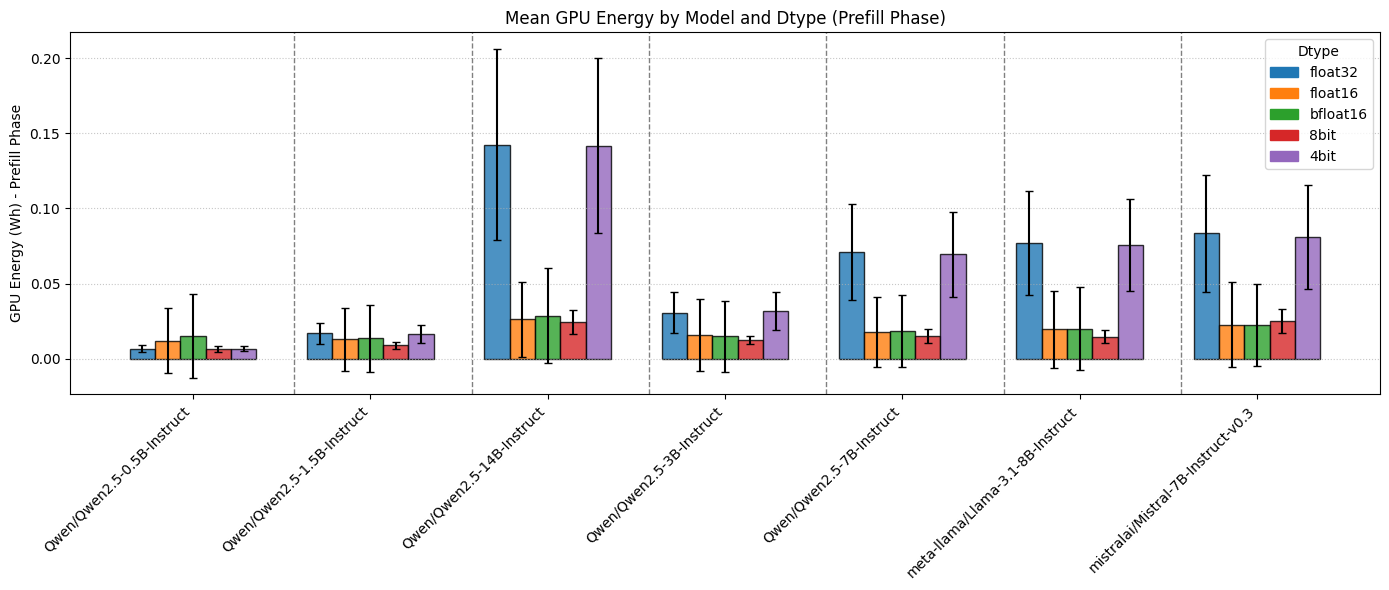

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import Patch

df = df_all_models_dtype.copy()
df['energy_prefill_gpu_Wh'] = df['energy_prefill_gpu'] * 1000

dtype_order = ['float32', 'float16', 'bfloat16', '8bit', '4bit']
df = df[df['dtype'].isin(dtype_order)]

agg = df.groupby(['model', 'dtype'])['energy_prefill_gpu_Wh'].agg(['mean', 'std']).reset_index()

models = agg['model'].unique()
n_models = len(models)
n_dtypes = len(dtype_order)
bar_width = 0.15
spacing = 0.3

colors = {
    'float32': '#1f77b4',
    'float16': '#ff7f0e',
    'bfloat16': '#2ca02c',
    '8bit': '#d62728',
    '4bit': '#9467bd'
}

x_pos = []
heights = []
errors = []
bar_colors = []

for i, model in enumerate(models):
    base = i * (n_dtypes * bar_width + spacing)
    model_data = agg[agg['model'] == model].set_index('dtype')
    for j, dtype in enumerate(dtype_order):
        xpos = base + j * bar_width
        x_pos.append(xpos)
        if dtype in model_data.index:
            heights.append(model_data.loc[dtype, 'mean'])
            errors.append(model_data.loc[dtype, 'std'])
        else:
            heights.append(0)
            errors.append(0)
        bar_colors.append(colors[dtype])

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(x_pos, heights, yerr=errors, capsize=3, width=bar_width, color=bar_colors, edgecolor='black', alpha=0.8)

for i in range(1, n_models):
    xpos = i * (n_dtypes * bar_width + spacing) - spacing / 2
    ax.axvline(x=xpos, color='gray', linestyle='--', linewidth=1)

ax.set_xticks([
    i * (n_dtypes * bar_width + spacing) + (n_dtypes - 1) * bar_width / 2
    for i in range(n_models)
])
ax.set_xticklabels(models, rotation=45, ha='right')

ax.set_ylabel("GPU Energy (Wh) - Prefill Phase")
ax.set_title("Mean GPU Energy by Model and Dtype (Prefill Phase)")
ax.grid(axis='y', linestyle=':', alpha=0.7)

legend_patches = [Patch(color=colors[d], label=d) for d in dtype_order]
ax.legend(handles=legend_patches, title="Dtype", loc="upper right")

plt.tight_layout()


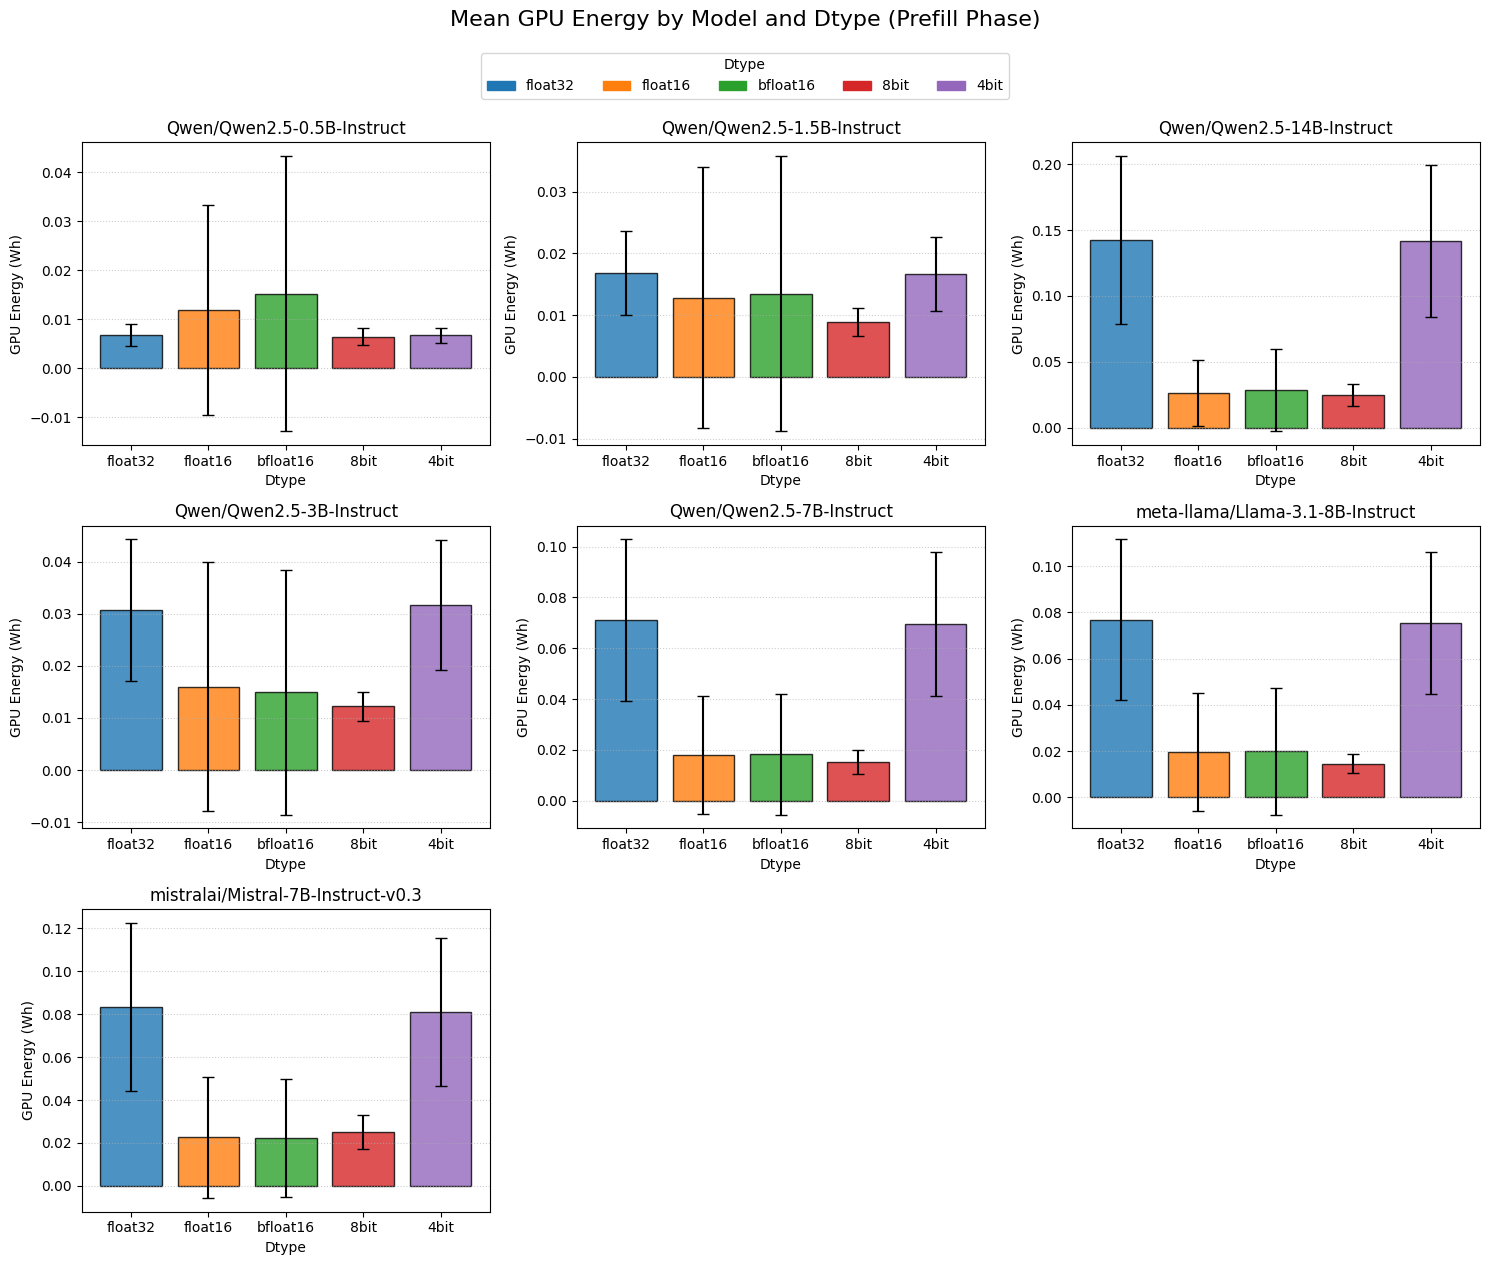

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from matplotlib.patches import Patch

df = df_all_models_dtype.copy()
df['energy_prefill_gpu_Wh'] = df['energy_prefill_gpu'] * 1000

dtype_order = ['float32', 'float16', 'bfloat16', '8bit', '4bit']
df = df[df['dtype'].isin(dtype_order)]

agg = df.groupby(['model', 'dtype'])['energy_prefill_gpu_Wh'].agg(['mean', 'std']).reset_index()
agg = agg.pivot(index='dtype', columns='model')

models = agg.columns.levels[1].tolist()
n_models = len(models)
n_cols = min(n_models, 3)
n_rows = (n_models + n_cols - 1) // n_cols

colors = {
    'float32': '#1f77b4',
    'float16': '#ff7f0e',
    'bfloat16': '#2ca02c',
    '8bit': '#d62728',
    '4bit': '#9467bd'
}

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows), squeeze=False)

for idx, model in enumerate(models):
    row, col = divmod(idx, n_cols)
    ax = axes[row][col]

    means = agg['mean'][model].reindex(dtype_order).fillna(0)
    stds = agg['std'][model].reindex(dtype_order).fillna(0)
    bar_colors = [colors[d] for d in dtype_order]

    ax.bar(dtype_order, means, yerr=stds, capsize=4, color=bar_colors, edgecolor='black', alpha=0.8)
    ax.set_title(model)
    ax.set_ylabel("GPU Energy (Wh)")
    ax.set_xlabel("Dtype")
    ax.grid(axis='y', linestyle=':', alpha=0.6)

for i in range(n_rows * n_cols):
    if i >= n_models:
        fig.delaxes(axes[i // n_cols][i % n_cols])

legend_patches = [Patch(color=colors[d], label=d) for d in dtype_order]
fig.legend(handles=legend_patches, title="Dtype", loc="upper center", ncol=len(dtype_order), bbox_to_anchor=(0.5, 1.02))
fig.suptitle("Mean GPU Energy by Model and Dtype (Prefill Phase)", fontsize=16, y=1.05)

plt.tight_layout()



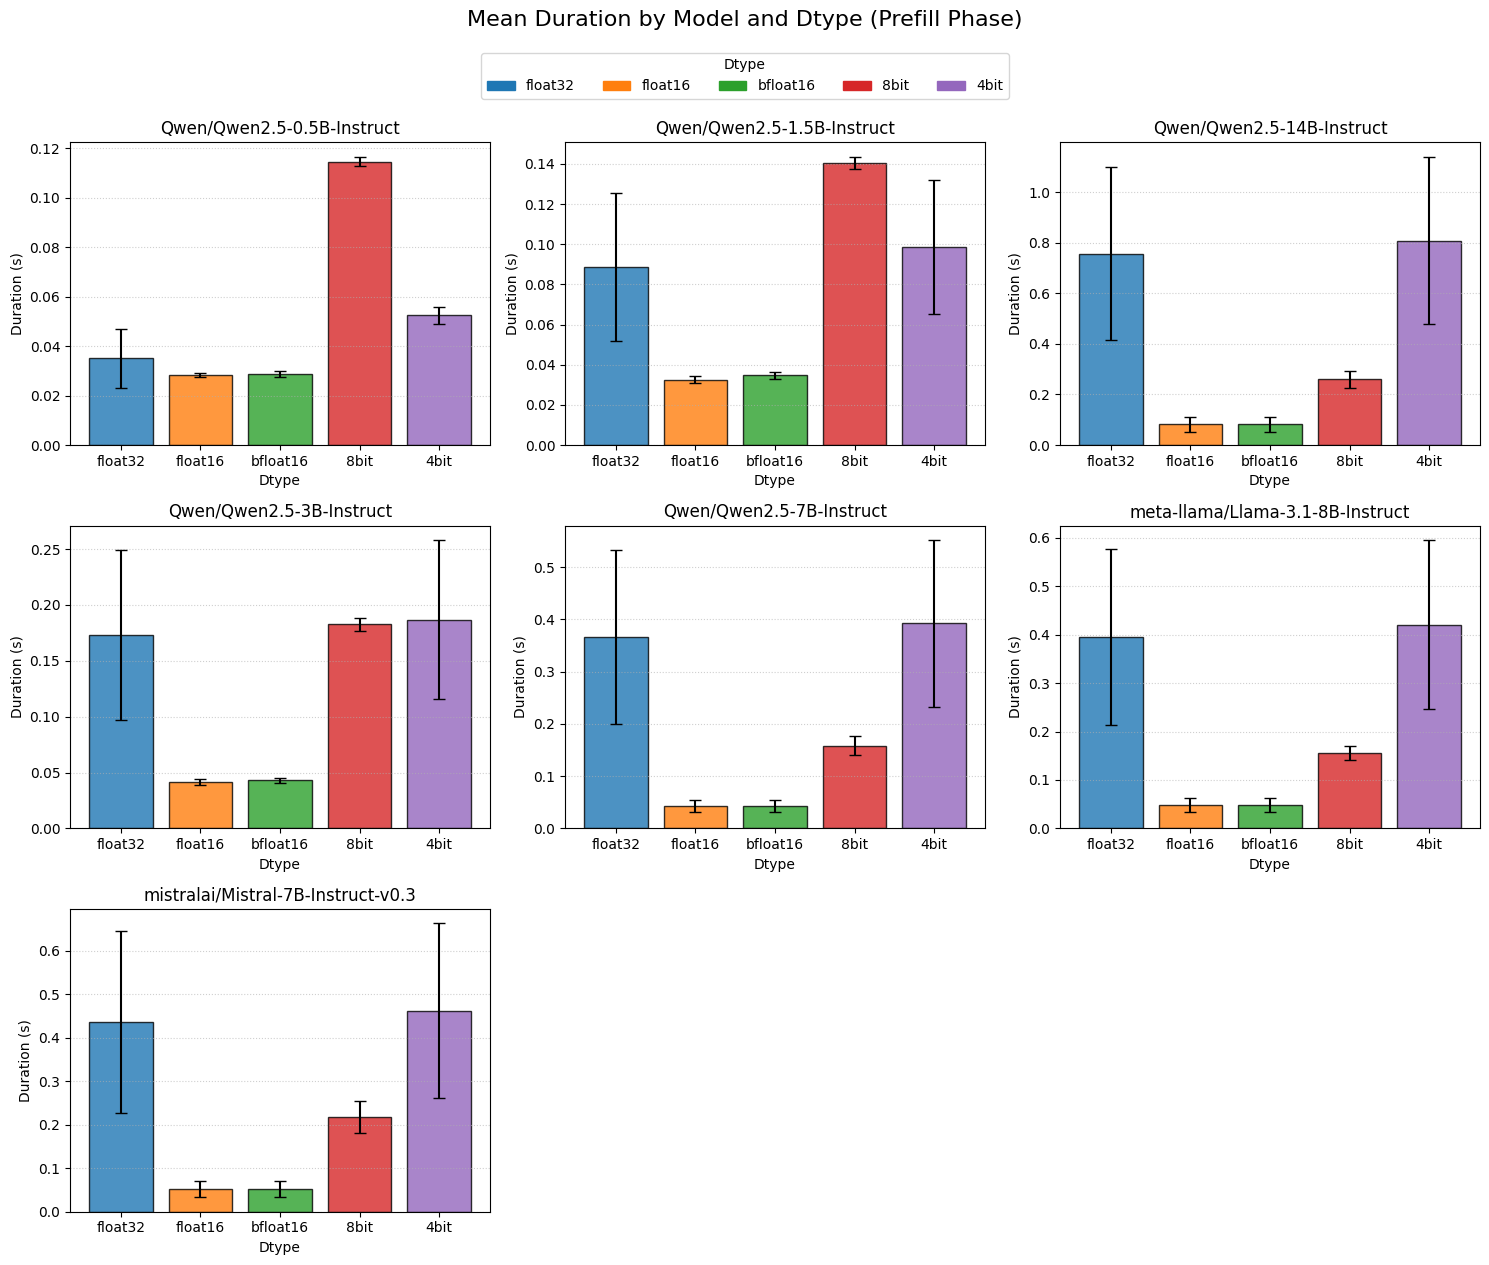

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from matplotlib.patches import Patch

df = df_all_models_dtype.copy()

dtype_order = ['float32', 'float16', 'bfloat16', '8bit', '4bit']
df = df[df['dtype'].isin(dtype_order)]

agg = df.groupby(['model', 'dtype'])['duration_prefill'].agg(['mean', 'std']).reset_index()
agg = agg.pivot(index='dtype', columns='model')

models = agg.columns.levels[1].tolist()
n_models = len(models)
n_cols = min(n_models, 3)
n_rows = (n_models + n_cols - 1) // n_cols

colors = {
    'float32': '#1f77b4',
    'float16': '#ff7f0e',
    'bfloat16': '#2ca02c',
    '8bit': '#d62728',
    '4bit': '#9467bd'
}

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows), squeeze=False)

for idx, model in enumerate(models):
    row, col = divmod(idx, n_cols)
    ax = axes[row][col]

    means = agg['mean'][model].reindex(dtype_order).fillna(0)
    stds = agg['std'][model].reindex(dtype_order).fillna(0)
    bar_colors = [colors[d] for d in dtype_order]

    ax.bar(dtype_order, means, yerr=stds, capsize=4, color=bar_colors, edgecolor='black', alpha=0.8)
    ax.set_title(model)
    ax.set_ylabel("Duration (s)")
    ax.set_xlabel("Dtype")
    ax.grid(axis='y', linestyle=':', alpha=0.6)

for i in range(n_rows * n_cols):
    if i >= n_models:
        fig.delaxes(axes[i // n_cols][i % n_cols])

legend_patches = [Patch(color=colors[d], label=d) for d in dtype_order]
fig.legend(handles=legend_patches, title="Dtype", loc="upper center", ncol=len(dtype_order), bbox_to_anchor=(0.5, 1.02))
fig.suptitle("Mean Duration by Model and Dtype (Prefill Phase)", fontsize=16, y=1.05)

plt.tight_layout()



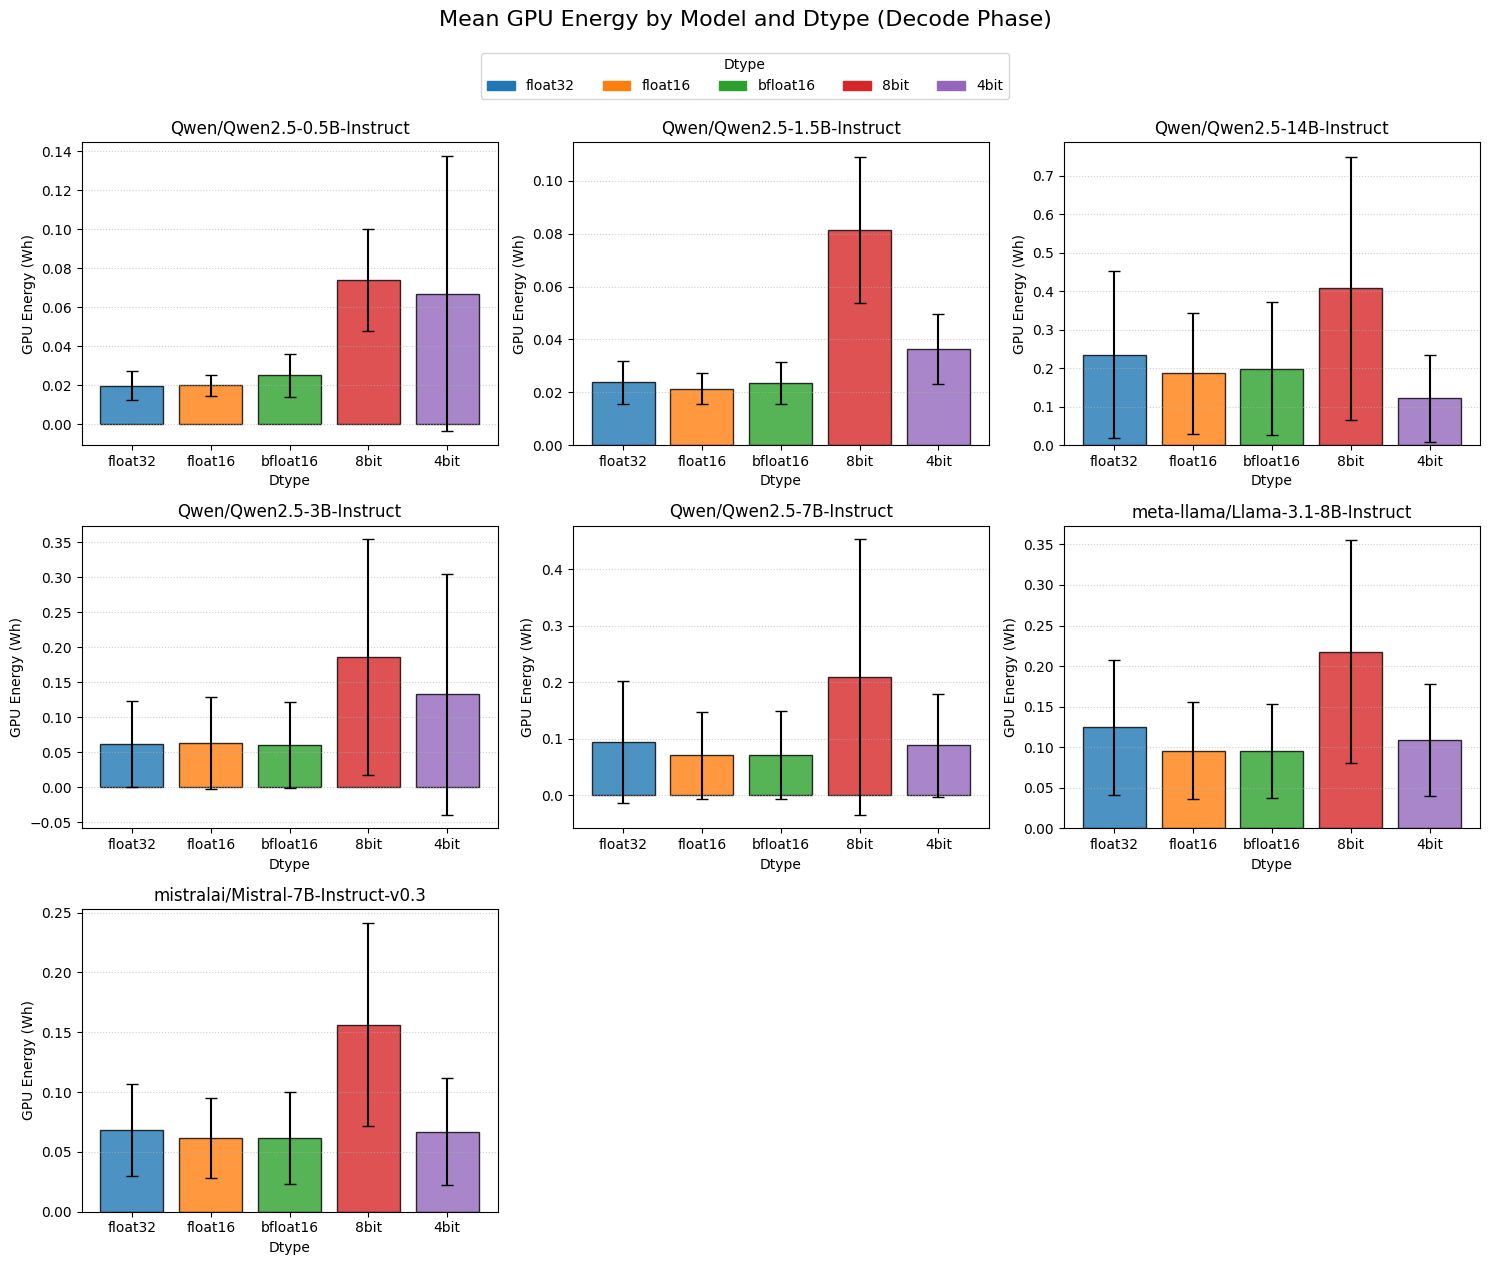

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from matplotlib.patches import Patch

df = df_all_models_dtype.copy()
df['energy_decode_gpu_Wh'] = df['energy_decode_gpu'] * 1000

dtype_order = ['float32', 'float16', 'bfloat16', '8bit', '4bit']
df = df[df['dtype'].isin(dtype_order)]

agg = df.groupby(['model', 'dtype'])['energy_decode_gpu_Wh'].agg(['mean', 'std']).reset_index()
agg = agg.pivot(index='dtype', columns='model')

models = agg.columns.levels[1].tolist()
n_models = len(models)
n_cols = min(n_models, 3)
n_rows = (n_models + n_cols - 1) // n_cols

colors = {
    'float32': '#1f77b4',
    'float16': '#ff7f0e',
    'bfloat16': '#2ca02c',
    '8bit': '#d62728',
    '4bit': '#9467bd'
}

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows), squeeze=False)

for idx, model in enumerate(models):
    row, col = divmod(idx, n_cols)
    ax = axes[row][col]

    means = agg['mean'][model].reindex(dtype_order).fillna(0)
    stds = agg['std'][model].reindex(dtype_order).fillna(0)
    bar_colors = [colors[d] for d in dtype_order]

    ax.bar(dtype_order, means, yerr=stds, capsize=4, color=bar_colors, edgecolor='black', alpha=0.8)
    ax.set_title(model)
    ax.set_ylabel("GPU Energy (Wh)")
    ax.set_xlabel("Dtype")
    ax.grid(axis='y', linestyle=':', alpha=0.6)

for i in range(n_rows * n_cols):
    if i >= n_models:
        fig.delaxes(axes[i // n_cols][i % n_cols])

legend_patches = [Patch(color=colors[d], label=d) for d in dtype_order]
fig.legend(handles=legend_patches, title="Dtype", loc="upper center", ncol=len(dtype_order), bbox_to_anchor=(0.5, 1.02))
fig.suptitle("Mean GPU Energy by Model and Dtype (Decode Phase)", fontsize=16, y=1.05)

plt.tight_layout()



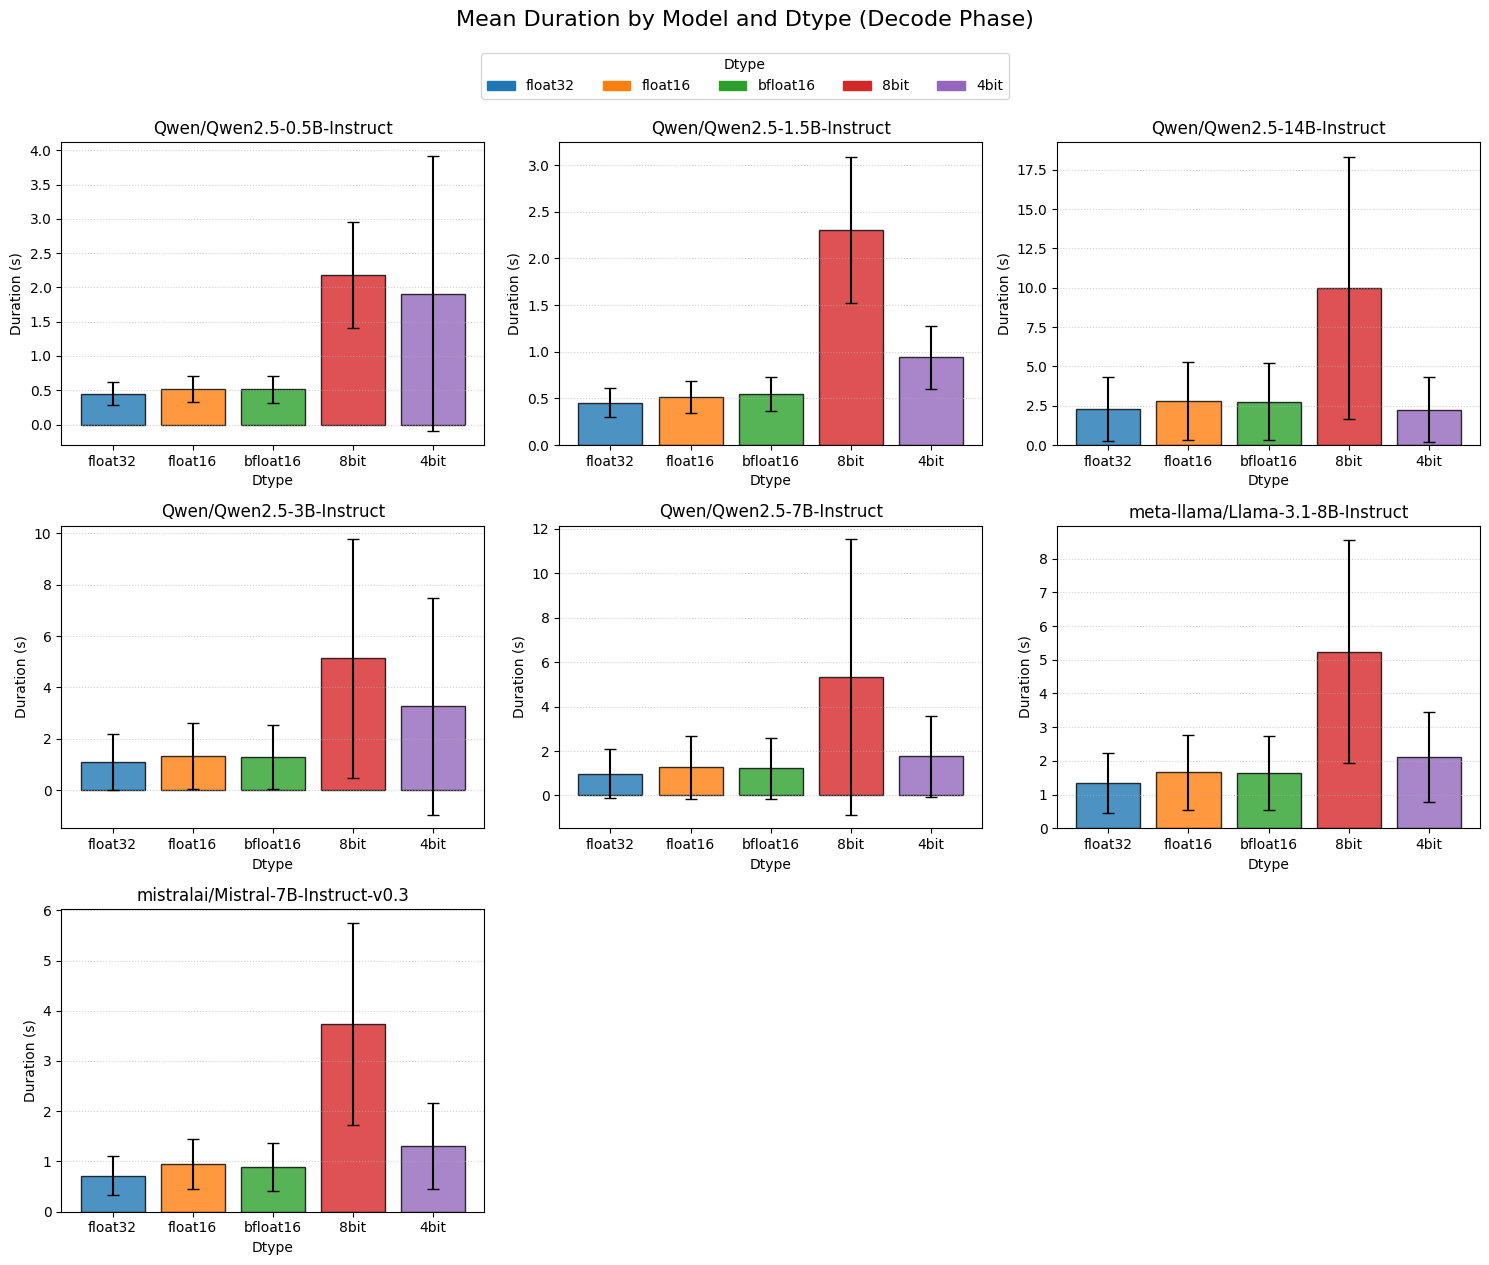

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from matplotlib.patches import Patch

df = df_all_models_dtype.copy()

dtype_order = ['float32', 'float16', 'bfloat16', '8bit', '4bit']
df = df[df['dtype'].isin(dtype_order)]

agg = df.groupby(['model', 'dtype'])['duration_decode'].agg(['mean', 'std']).reset_index()
agg = agg.pivot(index='dtype', columns='model')

models = agg.columns.levels[1].tolist()
n_models = len(models)
n_cols = min(n_models, 3)
n_rows = (n_models + n_cols - 1) // n_cols
colors = {
    'float32': '#1f77b4',
    'float16': '#ff7f0e',
    'bfloat16': '#2ca02c',
    '8bit': '#d62728',
    '4bit': '#9467bd'
}

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows), squeeze=False)

for idx, model in enumerate(models):
    row, col = divmod(idx, n_cols)
    ax = axes[row][col]

    means = agg['mean'][model].reindex(dtype_order).fillna(0)
    stds = agg['std'][model].reindex(dtype_order).fillna(0)
    bar_colors = [colors[d] for d in dtype_order]

    ax.bar(dtype_order, means, yerr=stds, capsize=4, color=bar_colors, edgecolor='black', alpha=0.8)
    ax.set_title(model)
    ax.set_ylabel("Duration (s)")
    ax.set_xlabel("Dtype")
    ax.grid(axis='y', linestyle=':', alpha=0.6)

for i in range(n_rows * n_cols):
    if i >= n_models:
        fig.delaxes(axes[i // n_cols][i % n_cols])

legend_patches = [Patch(color=colors[d], label=d) for d in dtype_order]
fig.legend(handles=legend_patches, title="Dtype", loc="upper center", ncol=len(dtype_order), bbox_to_anchor=(0.5, 1.02))
fig.suptitle("Mean Duration by Model and Dtype (Decode Phase)", fontsize=16, y=1.05)

plt.tight_layout()
plt.savefig('static/mean_duration_by_model_and_dtype_decode_phase.png')

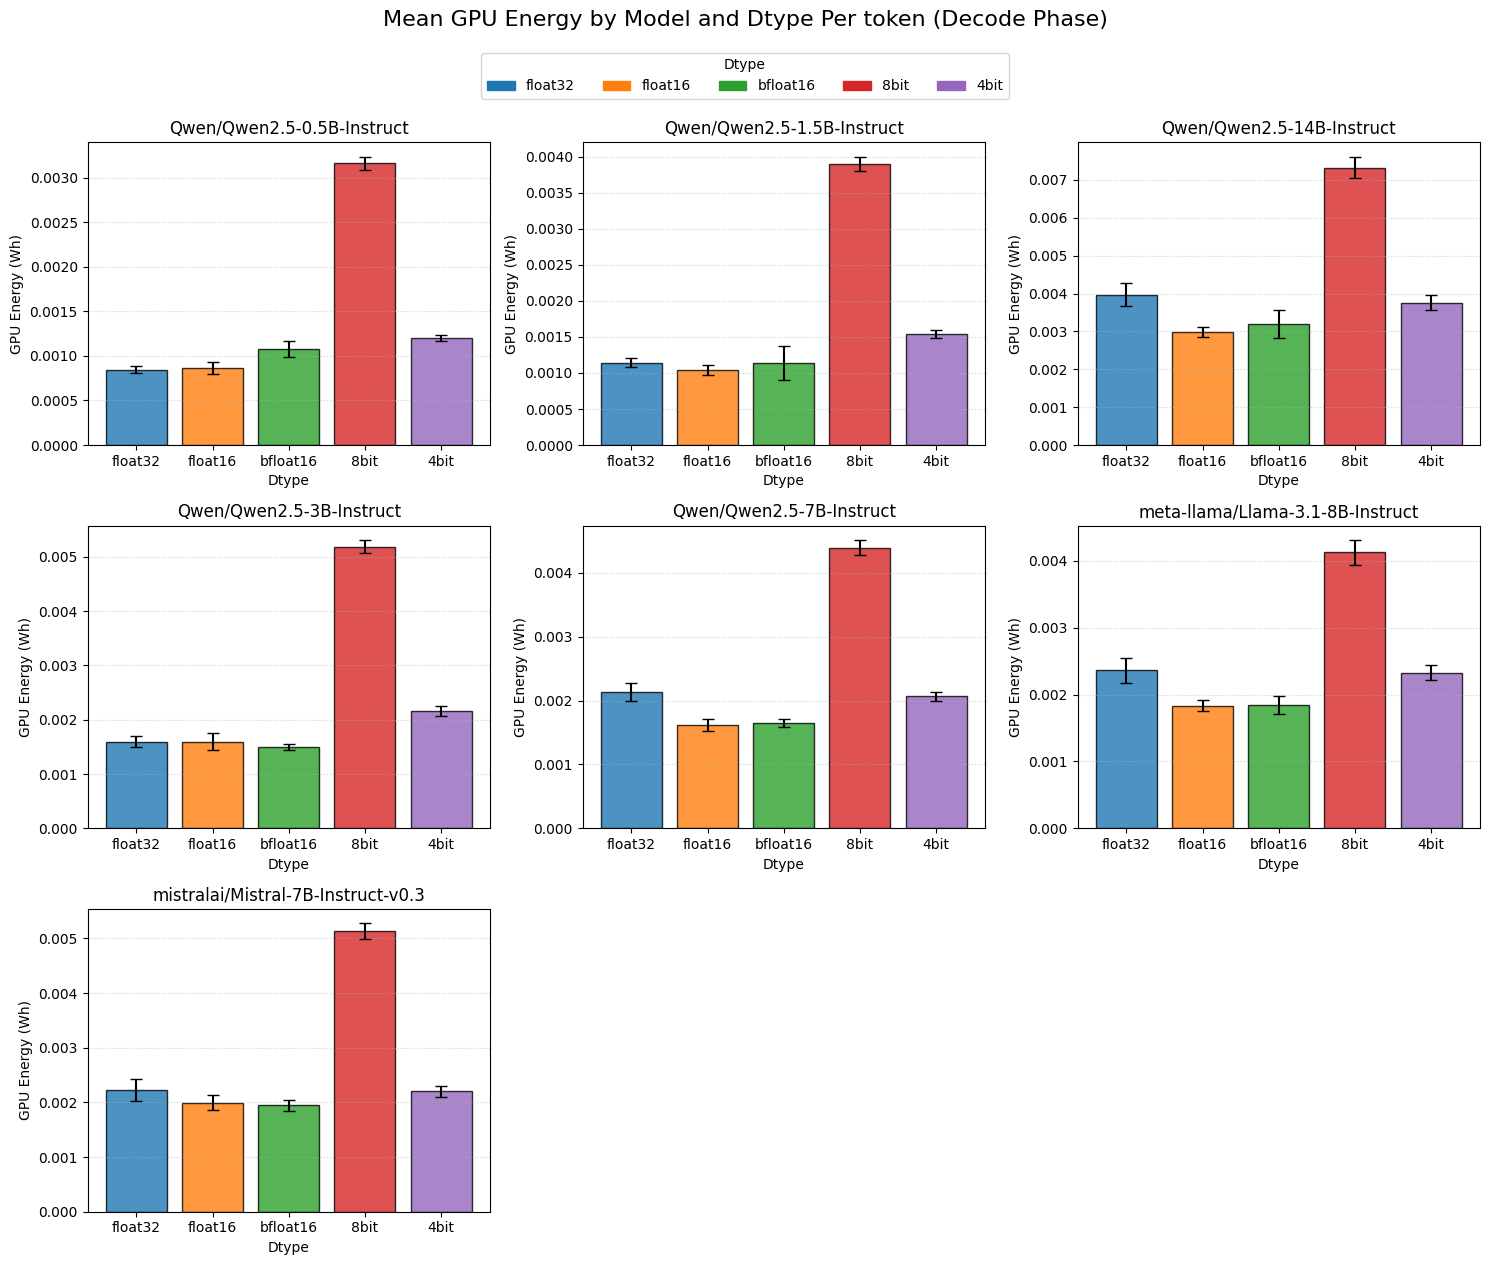

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from matplotlib.patches import Patch

df = df_all_models_dtype.copy()
df['energy_decode_gpu_Wh_per_token'] = df['energy_decode_gpu'] * 1000 / df['response_tokens']

dtype_order = ['float32', 'float16', 'bfloat16', '8bit', '4bit']
df = df[df['dtype'].isin(dtype_order)]

agg = df.groupby(['model', 'dtype'])['energy_decode_gpu_Wh_per_token'].agg(['mean', 'std']).reset_index()
agg = agg.pivot(index='dtype', columns='model')

models = agg.columns.levels[1].tolist()
n_models = len(models)
n_cols = min(n_models, 3)
n_rows = (n_models + n_cols - 1) // n_cols

colors = {
    'float32': '#1f77b4',
    'float16': '#ff7f0e',
    'bfloat16': '#2ca02c',
    '8bit': '#d62728',
    '4bit': '#9467bd'
}

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows), squeeze=False)

for idx, model in enumerate(models):
    row, col = divmod(idx, n_cols)
    ax = axes[row][col]

    means = agg['mean'][model].reindex(dtype_order).fillna(0)
    stds = agg['std'][model].reindex(dtype_order).fillna(0)
    bar_colors = [colors[d] for d in dtype_order]

    ax.bar(dtype_order, means, yerr=stds, capsize=4, color=bar_colors, edgecolor='black', alpha=0.8)
    ax.set_title(model)
    ax.set_ylabel("GPU Energy (Wh)")
    ax.set_xlabel("Dtype")
    ax.grid(axis='y', linestyle=':', alpha=0.6)

for i in range(n_rows * n_cols):
    if i >= n_models:
        fig.delaxes(axes[i // n_cols][i % n_cols])

legend_patches = [Patch(color=colors[d], label=d) for d in dtype_order]
fig.legend(handles=legend_patches, title="Dtype", loc="upper center", ncol=len(dtype_order), bbox_to_anchor=(0.5, 1.02))
fig.suptitle("Mean GPU Energy by Model and Dtype Per token (Decode Phase)", fontsize=16, y=1.05)

plt.tight_layout()



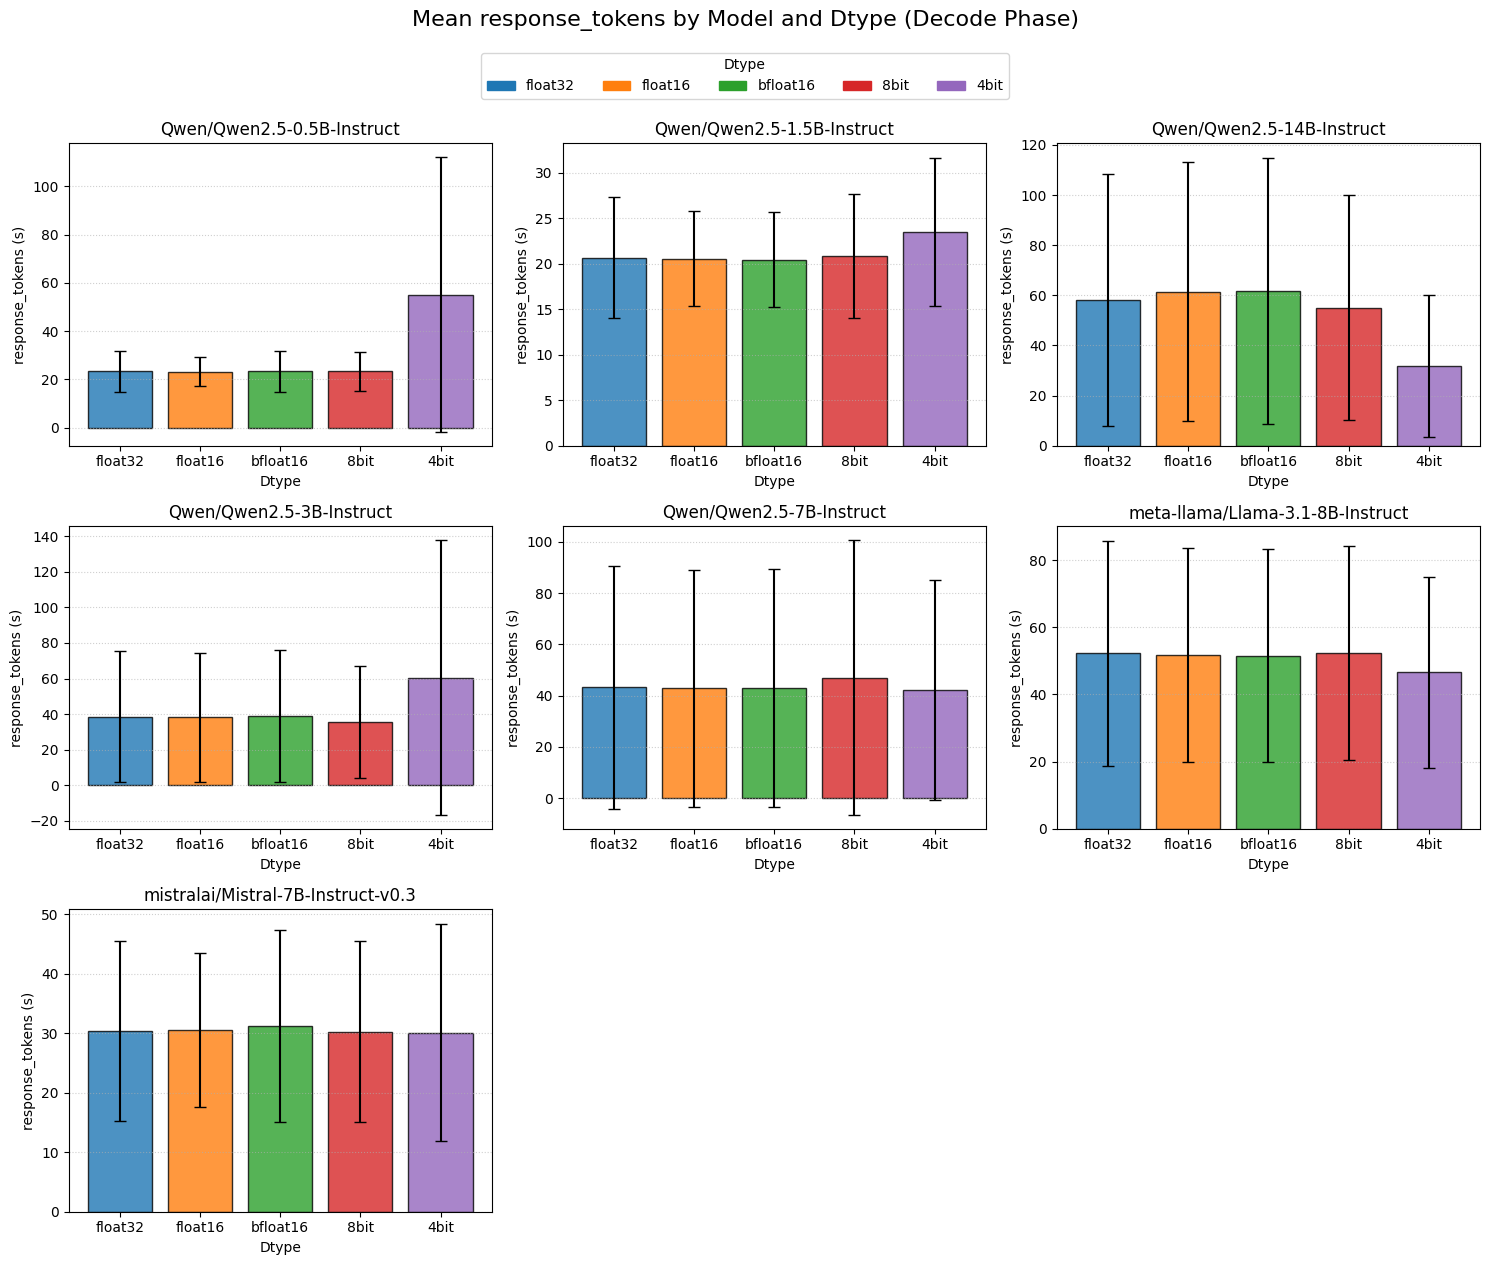

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from matplotlib.patches import Patch

df = df_all_models_dtype.copy()

dtype_order = ['float32', 'float16', 'bfloat16', '8bit', '4bit']
df = df[df['dtype'].isin(dtype_order)]

agg = df.groupby(['model', 'dtype'])['response_tokens'].agg(['mean', 'std']).reset_index()
agg = agg.pivot(index='dtype', columns='model')

models = agg.columns.levels[1].tolist()
n_models = len(models)
n_cols = min(n_models, 3)
n_rows = (n_models + n_cols - 1) // n_cols

colors = {
    'float32': '#1f77b4',
    'float16': '#ff7f0e',
    'bfloat16': '#2ca02c',
    '8bit': '#d62728',
    '4bit': '#9467bd'
}

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows), squeeze=False)

for idx, model in enumerate(models):
    row, col = divmod(idx, n_cols)
    ax = axes[row][col]

    means = agg['mean'][model].reindex(dtype_order).fillna(0)
    stds = agg['std'][model].reindex(dtype_order).fillna(0)
    bar_colors = [colors[d] for d in dtype_order]

    ax.bar(dtype_order, means, yerr=stds, capsize=4, color=bar_colors, edgecolor='black', alpha=0.8)
    ax.set_title(model)
    ax.set_ylabel("response_tokens (s)")
    ax.set_xlabel("Dtype")
    ax.grid(axis='y', linestyle=':', alpha=0.6)

for i in range(n_rows * n_cols):
    if i >= n_models:
        fig.delaxes(axes[i // n_cols][i % n_cols])

legend_patches = [Patch(color=colors[d], label=d) for d in dtype_order]
fig.legend(handles=legend_patches, title="Dtype", loc="upper center", ncol=len(dtype_order), bbox_to_anchor=(0.5, 1.02))
fig.suptitle("Mean response_tokens by Model and Dtype (Decode Phase)", fontsize=16, y=1.05)

plt.tight_layout()



## Static batching

In [2]:
df_llama8B_batch1 = pd.read_csv(FOLDER + "Llama-3.1-8B-Instruct-ultrachat_200k-Llama-3-8B-Instruct-with-thanks-energy-2025-05-31-10-44-37.csv")
df_llama8B_batch2 = pd.read_csv(FOLDER + "Llama-3.1-8B-Instruct-ultrachat_200k-Llama-3-8B-Instruct-with-thanks-energy-batch2-2025-06-02-12-07-52.csv")
df_llama8B_batch4 = pd.read_csv(FOLDER + "Llama-3.1-8B-Instruct-ultrachat_200k-Llama-3-8B-Instruct-with-thanks-energy-batch4-2025-06-02-12-07-17.csv")
df_llama8B_batch8 = pd.read_csv(FOLDER + "Llama-3.1-8B-Instruct-ultrachat_200k-Llama-3-8B-Instruct-with-thanks-energy-batch8-2025-06-02-12-07-04.csv")
df_llama8B_batch16 = pd.read_csv(FOLDER + "Llama-3.1-8B-Instruct-ultrachat_200k-Llama-3-8B-Instruct-with-thanks-energy-batch-2025-06-02-12-04-38.csv")

In [3]:
df_llama8B_batch1

,Unnamed: 0,model,dataset,split,column,prompt_tokens,response_tokens,duration_prefill,duration_generate,duration_decode,energy_prefill_cpu,energy_prefill_gpu,energy_prefill_ram,energy_generate_cpu,energy_generate_gpu,energy_generate_ram,energy_decode_cpu,energy_decode_gpu,energy_decode_ram
0,0,meta-llama/Llama-3.1-8B-Instruct,jdelavande/ultrachat_200k-Llama-3-8B-Instruct-...,train,conversation_with_thanks,683,47,0.243993,1.374374,1.130381,0.000004,0.000043,0.000003,0.000018,0.000141,0.000015,0.000014,0.000098,0.000012
1,1,meta-llama/Llama-3.1-8B-Instruct,jdelavande/ultrachat_200k-Llama-3-8B-Instruct-...,train,conversation_with_thanks,1488,45,0.499466,1.581464,1.081998,0.000007,0.000089,0.000006,0.000020,0.000196,0.000017,0.000014,0.000108,0.000011
2,2,meta-llama/Llama-3.1-8B-Instruct,jdelavande/ultrachat_200k-Llama-3-8B-Instruct-...,train,conversation_with_thanks,2999,69,0.956044,2.804570,1.848526,0.000013,0.000178,0.000011,0.000036,0.000374,0.000030,0.000023,0.000196,0.000020
3,3,meta-llama/Llama-3.1-8B-Instruct,jdelavande/ultrachat_200k-Llama-3-8B-Instruct-...,train,conversation_with_thanks,410,38,0.147575,1.058437,0.910862,0.000002,0.000031,0.000002,0.000014,0.000110,0.000012,0.000011,0.000080,0.000010
4,4,meta-llama/Llama-3.1-8B-Instruct,jdelavande/ultrachat_200k-Llama-3-8B-Instruct-...,train,conversation_with_thanks,2156,53,0.764414,2.056390,1.291976,0.000010,0.000143,0.000009,0.000026,0.000281,0.000022,0.000016,0.000138,0.000014
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9995,meta-llama/Llama-3.1-8B-Instruct,jdelavande/ultrachat_200k-Llama-3-8B-Instruct-...,train,conversation_with_thanks,966,37,0.332717,1.244684,0.911968,0.000005,0.000066,0.000004,0.000017,0.000148,0.000014,0.000012,0.000082,0.000010
9996,9996,meta-llama/Llama-3.1-8B-Instruct,jdelavande/ultrachat_200k-Llama-3-8B-Instruct-...,train,conversation_with_thanks,1308,39,0.428730,1.405598,0.976868,0.000006,0.000084,0.000005,0.000019,0.000178,0.000015,0.000013,0.000094,0.000010
9997,9997,meta-llama/Llama-3.1-8B-Instruct,jdelavande/ultrachat_200k-Llama-3-8B-Instruct-...,train,conversation_with_thanks,790,81,0.264035,2.354033,2.089998,0.000004,0.000052,0.000003,0.000031,0.000236,0.000025,0.000027,0.000184,0.000022
9998,9998,meta-llama/Llama-3.1-8B-Instruct,jdelavande/ultrachat_200k-Llama-3-8B-Instruct-...,train,conversation_with_thanks,482,18,0.166148,0.589201,0.423053,0.000003,0.000032,0.000002,0.000008,0.000069,0.000007,0.000006,0.000037,0.000004


In [4]:
df_llama8B_batch1['prompt_tokens'] = df_llama8B_batch1['prompt_tokens'].apply(lambda x: str([x]) if isinstance(x, int) else x)
df_llama8B_batch1['response_tokens'] = df_llama8B_batch1['response_tokens'].apply(lambda x: str([x]) if isinstance(x, int) else x)

In [5]:
df_llama8B_batch16['energy_generate_gpu'].mean() * 1000, df_llama8B_batch16['energy_generate_cpu'].mean() * 1000, df_llama8B_batch16['energy_generate_ram'].mean() * 1000

(3.9683549145618153, 0.3628041796697609, 0.24664340177782929)

In [6]:
df_llama8B_batch16['energy_generate_gpu'].mean() * 1000 / 16

0.24802218216011346

In [7]:
print(f"=== Llama 8B batch 1 ===")
print(f"min energy_generate_gpu per gen llama 8B batch 1: {df_llama8B_batch1['energy_generate_gpu'].min() * 1000 / 1} Wh")
print(f"max energy_generate_gpu per gen llama 8B batch 1: {df_llama8B_batch1['energy_generate_gpu'].max() * 1000 / 1} Wh")
print(f"mean energy_generate_gpu per gen llama 8B batch 1: {df_llama8B_batch1['energy_generate_gpu'].mean() * 1000 / 1} Wh")
print(f"std energy_generate_gpu per gen llama 8B batch 1: {df_llama8B_batch1['energy_generate_gpu'].std() * 1000 / 1} Wh")
print(f"=== Llama 8B batch 2 ===")
print(f"min energy_generate_gpu per gen llama 8B batch 2: {df_llama8B_batch2['energy_generate_gpu'].min() * 1000 / 2} Wh")
print(f"max energy_generate_gpu per gen llama 8B batch 2: {df_llama8B_batch2['energy_generate_gpu'].max() * 1000 / 2} Wh")
print(f"mean energy_generate_gpu per gen llama 8B batch 2: {df_llama8B_batch2['energy_generate_gpu'].mean() * 1000 / 2} Wh")
print(f"std energy_generate_gpu per gen llama 8B batch 2: {df_llama8B_batch2['energy_generate_gpu'].std() * 1000 / 2} Wh")
print(f"=== Llama 8B batch 4 ===")
print(f"min energy_generate_gpu per gen llama 8B batch 4: {df_llama8B_batch4['energy_generate_gpu'].min() * 1000 / 4} Wh")
print(f"max energy_generate_gpu per gen llama 8B batch 4: {df_llama8B_batch4['energy_generate_gpu'].max() * 1000 / 4} Wh")
print(f"mean energy_generate_gpu per gen llama 8B batch 4: {df_llama8B_batch4['energy_generate_gpu'].mean() * 1000 / 4} Wh")
print(f"std energy_generate_gpu per gen llama 8B batch 4: {df_llama8B_batch4['energy_generate_gpu'].std() * 1000 / 4} Wh")
print(f"=== Llama 8B batch 8 ===")
print(f"min energy_generate_gpu per gen llama 8B batch 8: {df_llama8B_batch8['energy_generate_gpu'].min() * 1000 / 8} Wh")
print(f"max energy_generate_gpu per gen llama 8B batch 8: {df_llama8B_batch8['energy_generate_gpu'].max() * 1000 / 8} Wh")
print(f"mean energy_generate_gpu per gen llama 8B batch 8: {df_llama8B_batch8['energy_generate_gpu'].mean() * 1000 / 8} Wh")
print(f"std energy_generate_gpu per gen llama 8B batch 8: {df_llama8B_batch8['energy_generate_gpu'].std() * 1000 / 8} Wh")
print(f"=== Llama 8B batch 16 ===")
print(f"min energy_generate_gpu per gen llama 8B batch 16: {df_llama8B_batch16['energy_generate_gpu'].min() * 1000 / 16} Wh")
print(f"max energy_generate_gpu per gen llama 8B batch 16: {df_llama8B_batch16['energy_generate_gpu'].max() * 1000 / 16} Wh")
print(f"mean energy_generate_gpu per gen llama 8B batch 16: {df_llama8B_batch16['energy_generate_gpu'].mean() * 1000 / 16} Wh")
print(f"std energy_generate_gpu per gen llama 8B batch 16: {df_llama8B_batch16['energy_generate_gpu'].std() * 1000 / 16} Wh")

=== Llama 8B batch 1 ===
min energy_generate_gpu per gen llama 8B batch 1: 0.03781814136658568 Wh
max energy_generate_gpu per gen llama 8B batch 1: 1.0092505296221 Wh
mean energy_generate_gpu per gen llama 8B batch 1: 0.20173698367551332 Wh
std energy_generate_gpu per gen llama 8B batch 1: 0.09615312398758515 Wh
=== Llama 8B batch 2 ===
min energy_generate_gpu per gen llama 8B batch 2: 0.04466885517970809 Wh
max energy_generate_gpu per gen llama 8B batch 2: 0.72055597922185 Wh
mean energy_generate_gpu per gen llama 8B batch 2: 0.1756328343589057 Wh
std energy_generate_gpu per gen llama 8B batch 2: 0.08482870449582236 Wh
=== Llama 8B batch 4 ===
min energy_generate_gpu per gen llama 8B batch 4: 0.059971950755325 Wh
max energy_generate_gpu per gen llama 8B batch 4: 0.60266098212835 Wh
mean energy_generate_gpu per gen llama 8B batch 4: 0.19026428260018324 Wh
std energy_generate_gpu per gen llama 8B batch 4: 0.08963475277555077 Wh
=== Llama 8B batch 8 ===
min energy_generate_gpu per gen ll

In [8]:
df_llama8B_batch2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Unnamed: 0           5000 non-null   int64  
 1   model                5000 non-null   object 
 2   dataset              5000 non-null   object 
 3   split                5000 non-null   object 
 4   column               5000 non-null   object 
 5   prompt_tokens        5000 non-null   object 
 6   response_tokens      5000 non-null   object 
 7   duration_prefill     5000 non-null   float64
 8   duration_generate    5000 non-null   float64
 9   duration_decode      5000 non-null   float64
 10  energy_prefill_cpu   5000 non-null   float64
 11  energy_prefill_gpu   5000 non-null   float64
 12  energy_prefill_ram   5000 non-null   float64
 13  energy_generate_cpu  5000 non-null   float64
 14  energy_generate_gpu  5000 non-null   float64
 15  energy_generate_ram  5000 non-null   f

In [9]:
df_llama8B_batch1

,Unnamed: 0,model,dataset,split,column,prompt_tokens,response_tokens,duration_prefill,duration_generate,duration_decode,energy_prefill_cpu,energy_prefill_gpu,energy_prefill_ram,energy_generate_cpu,energy_generate_gpu,energy_generate_ram,energy_decode_cpu,energy_decode_gpu,energy_decode_ram
0,0,meta-llama/Llama-3.1-8B-Instruct,jdelavande/ultrachat_200k-Llama-3-8B-Instruct-...,train,conversation_with_thanks,[683],[47],0.243993,1.374374,1.130381,0.000004,0.000043,0.000003,0.000018,0.000141,0.000015,0.000014,0.000098,0.000012
1,1,meta-llama/Llama-3.1-8B-Instruct,jdelavande/ultrachat_200k-Llama-3-8B-Instruct-...,train,conversation_with_thanks,[1488],[45],0.499466,1.581464,1.081998,0.000007,0.000089,0.000006,0.000020,0.000196,0.000017,0.000014,0.000108,0.000011
2,2,meta-llama/Llama-3.1-8B-Instruct,jdelavande/ultrachat_200k-Llama-3-8B-Instruct-...,train,conversation_with_thanks,[2999],[69],0.956044,2.804570,1.848526,0.000013,0.000178,0.000011,0.000036,0.000374,0.000030,0.000023,0.000196,0.000020
3,3,meta-llama/Llama-3.1-8B-Instruct,jdelavande/ultrachat_200k-Llama-3-8B-Instruct-...,train,conversation_with_thanks,[410],[38],0.147575,1.058437,0.910862,0.000002,0.000031,0.000002,0.000014,0.000110,0.000012,0.000011,0.000080,0.000010
4,4,meta-llama/Llama-3.1-8B-Instruct,jdelavande/ultrachat_200k-Llama-3-8B-Instruct-...,train,conversation_with_thanks,[2156],[53],0.764414,2.056390,1.291976,0.000010,0.000143,0.000009,0.000026,0.000281,0.000022,0.000016,0.000138,0.000014
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9995,meta-llama/Llama-3.1-8B-Instruct,jdelavande/ultrachat_200k-Llama-3-8B-Instruct-...,train,conversation_with_thanks,[966],[37],0.332717,1.244684,0.911968,0.000005,0.000066,0.000004,0.000017,0.000148,0.000014,0.000012,0.000082,0.000010
9996,9996,meta-llama/Llama-3.1-8B-Instruct,jdelavande/ultrachat_200k-Llama-3-8B-Instruct-...,train,conversation_with_thanks,[1308],[39],0.428730,1.405598,0.976868,0.000006,0.000084,0.000005,0.000019,0.000178,0.000015,0.000013,0.000094,0.000010
9997,9997,meta-llama/Llama-3.1-8B-Instruct,jdelavande/ultrachat_200k-Llama-3-8B-Instruct-...,train,conversation_with_thanks,[790],[81],0.264035,2.354033,2.089998,0.000004,0.000052,0.000003,0.000031,0.000236,0.000025,0.000027,0.000184,0.000022
9998,9998,meta-llama/Llama-3.1-8B-Instruct,jdelavande/ultrachat_200k-Llama-3-8B-Instruct-...,train,conversation_with_thanks,[482],[18],0.166148,0.589201,0.423053,0.000003,0.000032,0.000002,0.000008,0.000069,0.000007,0.000006,0.000037,0.000004


In [10]:
df_llama8B_batch2

,Unnamed: 0,model,dataset,split,column,prompt_tokens,response_tokens,duration_prefill,duration_generate,duration_decode,energy_prefill_cpu,energy_prefill_gpu,energy_prefill_ram,energy_generate_cpu,energy_generate_gpu,energy_generate_ram,energy_decode_cpu,energy_decode_gpu,energy_decode_ram,batch_size
0,0,meta-llama/Llama-3.1-8B-Instruct,jdelavande/ultrachat_200k-Llama-3-8B-Instruct-...,train,conversation_with_thanks,"[683, 1488]","[850, 45]",0.955618,2.124310,1.168692,0.000020,0.000161,0.000011,0.000046,0.000282,0.000023,0.000027,0.000122,0.000012,2
1,1,meta-llama/Llama-3.1-8B-Instruct,jdelavande/ultrachat_200k-Llama-3-8B-Instruct-...,train,conversation_with_thanks,"[2999, 410]","[69, 2658]",1.948693,4.201021,2.252327,0.000044,0.000333,0.000021,0.000082,0.000584,0.000045,0.000038,0.000251,0.000024,2
2,2,meta-llama/Llama-3.1-8B-Instruct,jdelavande/ultrachat_200k-Llama-3-8B-Instruct-...,train,conversation_with_thanks,"[2156, 1237]","[53, 972]",1.425741,2.925326,1.499586,0.000026,0.000251,0.000016,0.000055,0.000410,0.000031,0.000029,0.000159,0.000016,2
3,3,meta-llama/Llama-3.1-8B-Instruct,jdelavande/ultrachat_200k-Llama-3-8B-Instruct-...,train,conversation_with_thanks,"[1414, 1150]","[107, 371]",0.909003,3.726014,2.817011,0.000017,0.000160,0.000010,0.000066,0.000457,0.000040,0.000049,0.000297,0.000030,2
4,4,meta-llama/Llama-3.1-8B-Instruct,jdelavande/ultrachat_200k-Llama-3-8B-Instruct-...,train,conversation_with_thanks,"[1965, 1311]","[46, 700]",1.270175,2.510060,1.239886,0.000024,0.000218,0.000014,0.000043,0.000356,0.000027,0.000018,0.000138,0.000013,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,4995,meta-llama/Llama-3.1-8B-Instruct,jdelavande/ultrachat_200k-Llama-3-8B-Instruct-...,train,conversation_with_thanks,"[408, 775]","[410, 43]",0.517415,1.644496,1.127082,0.000007,0.000095,0.000006,0.000021,0.000202,0.000018,0.000014,0.000108,0.000012,2
4996,4996,meta-llama/Llama-3.1-8B-Instruct,jdelavande/ultrachat_200k-Llama-3-8B-Instruct-...,train,conversation_with_thanks,"[1671, 2342]","[731, 60]",1.532089,3.284881,1.752792,0.000020,0.000275,0.000017,0.000042,0.000477,0.000035,0.000022,0.000202,0.000019,2
4997,4997,meta-llama/Llama-3.1-8B-Instruct,jdelavande/ultrachat_200k-Llama-3-8B-Instruct-...,train,conversation_with_thanks,"[1643, 966]","[54, 731]",1.101838,2.518326,1.416488,0.000014,0.000195,0.000012,0.000032,0.000350,0.000027,0.000018,0.000155,0.000015,2
4998,4998,meta-llama/Llama-3.1-8B-Instruct,jdelavande/ultrachat_200k-Llama-3-8B-Instruct-...,train,conversation_with_thanks,"[1308, 790]","[39, 557]",0.843803,1.845341,1.001538,0.000011,0.000157,0.000009,0.000024,0.000264,0.000020,0.000013,0.000107,0.000011,2


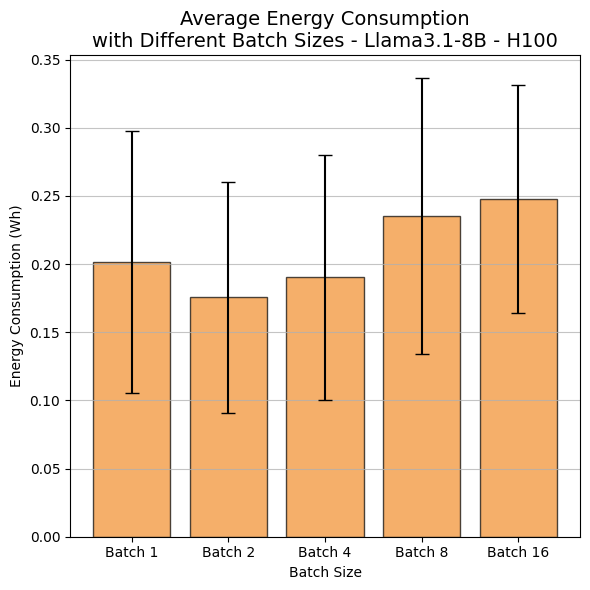

<Figure size 640x480 with 0 Axes>

In [11]:
colors = ['#4E79A7', '#F28E2B', '#59A14F']
dfs_batches = [df_llama8B_batch1, df_llama8B_batch2, df_llama8B_batch4, df_llama8B_batch8, df_llama8B_batch16]
batch_sizes = [1, 2, 4, 8, 16]
means = [df['energy_generate_gpu'].mean() * 1000 / size for df, size in zip(dfs_batches, batch_sizes)]
std = [df['energy_generate_gpu'].std() * 1000 / size for df, size in zip(dfs_batches, batch_sizes)]
import matplotlib.pyplot as plt
import numpy as np
# Plotting the energy consumption for different batch sizes

fig, ax = plt.subplots(figsize=(6, 6))
x_pos = np.arange(len(batch_sizes))
ax.bar(x_pos, means, yerr=std, capsize=5, color=colors[1], alpha=0.7, edgecolor='black')
ax.set_xticks(x_pos)
ax.set_xticklabels([f'Batch {size}' for size in batch_sizes])
ax.set_title('Average Energy Consumption\nwith Different Batch Sizes - Llama3.1-8B - H100', fontsize=14)
ax.set_ylabel('Energy Consumption (Wh)')
ax.set_xlabel('Batch Size')
ax.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()
plt.savefig('static/average_energy_consumption_llama8B_batch_sizes.png')
    

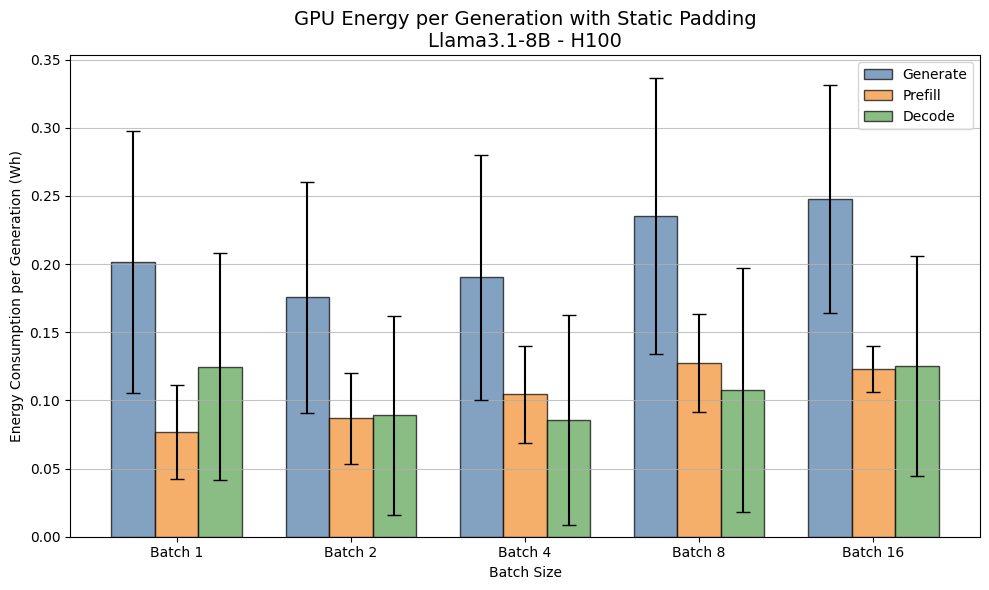

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

phases = ['generate', 'prefill', 'decode']
means = {phase: [] for phase in phases}
stds = {phase: [] for phase in phases}
colors = ['#4E79A7', '#F28E2B', '#59A14F']

for df, size in zip(dfs_batches, batch_sizes):
    for phase in phases:
        mean = df[f'energy_{phase}_gpu'].mean() * 1000 / size 
        std = df[f'energy_{phase}_gpu'].std() * 1000 / size
        means[phase].append(mean)
        stds[phase].append(std)

x = np.arange(len(batch_sizes))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))
for i, phase in enumerate(phases):
    offset = (i - 1) * width
    ax.bar(x + offset, means[phase], width, yerr=stds[phase], capsize=5,
           label=phase.capitalize(), alpha=0.7, edgecolor='black', color=colors[i])

ax.set_xticks(x)
ax.set_xticklabels([f'Batch {size}' for size in batch_sizes])
ax.set_title('GPU Energy per Generation with Static Padding\nLlama3.1-8B - H100', fontsize=14)
ax.set_ylabel('Energy Consumption per Generation (Wh)')
ax.set_xlabel('Batch Size')
ax.grid(axis='y', alpha=0.75)
ax.legend()
plt.tight_layout()
plt.savefig('static/energy_consumption_per_generation_llama8B_batch_sizes.png')
plt.show()



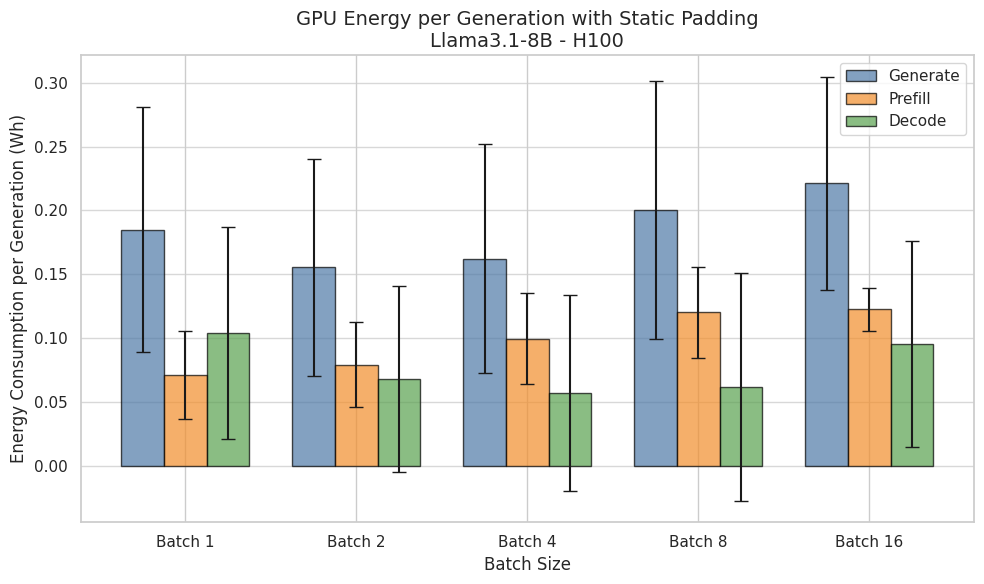

<Figure size 640x480 with 0 Axes>

: 

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

phases = ['generate', 'prefill', 'decode']
means = {phase: [] for phase in phases}
stds = {phase: [] for phase in phases}
colors = ['#4E79A7', '#F28E2B', '#59A14F']

for df, size in zip(dfs_batches, batch_sizes):
    for phase in phases:
        mean = df[f'energy_{phase}_gpu'].median() * 1000 / size
        std = df[f'energy_{phase}_gpu'].std() * 1000 / size
        means[phase].append(mean)
        stds[phase].append(std)

x = np.arange(len(batch_sizes))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))
for i, phase in enumerate(phases):
    offset = (i - 1) * width
    ax.bar(x + offset, means[phase], width, yerr=stds[phase], capsize=5,
           label=phase.capitalize(), alpha=0.7, edgecolor='black', color=colors[i])

ax.set_xticks(x)
ax.set_xticklabels([f'Batch {size}' for size in batch_sizes])
ax.set_title('GPU Energy per Generation with Static Padding\nLlama3.1-8B - H100', fontsize=14)
ax.set_ylabel('Energy Consumption per Generation (Wh)')
ax.set_xlabel('Batch Size')
ax.grid(axis='y', alpha=0.75)
ax.legend()
plt.tight_layout()
plt.show()
plt.savefig('static/energy_consumption_per_generation_llama8B_batch_sizes_median.png')


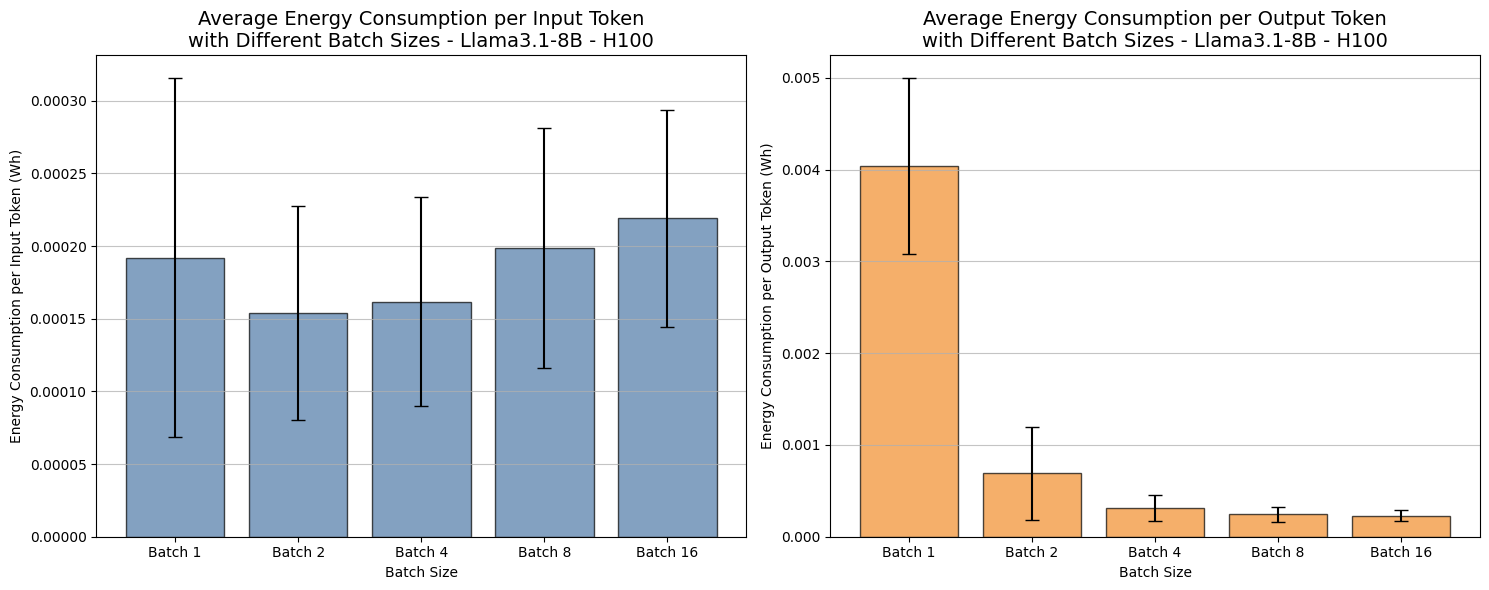

In [ ]:
means_per_input_tokens = []
std_per_input_tokens = []
means_per_output_tokens = []
std_per_output_tokens = []
colors = ['#4E79A7', '#F28E2B', '#59A14F']
for df in dfs_batches:
    df['prompt_tokens_all_batch'] = df['prompt_tokens'].apply(lambda x: sum(eval(x)))
    df['energy_gpu_generate_per_input_token'] = df['energy_generate_gpu'] * 1000 / (df['prompt_tokens_all_batch'])
    df['energy_gpu_decode_per_input_token'] = df['energy_decode_gpu'] * 1000 / (df['prompt_tokens_all_batch'])
    df['energy_gpu_prefill_per_input_token'] = df['energy_prefill_gpu'] * 1000 / (df['prompt_tokens_all_batch'])

    df['response_tokens_all_batch'] = df['response_tokens'].apply(lambda x: sum(eval(x)))
    df['energy_generate_gpu_per_output_token'] = df['energy_generate_gpu'] * 1000 / (df['response_tokens_all_batch'])
    df['energy_decode_gpu_per_output_token'] = df['energy_decode_gpu'] * 1000 / (df['response_tokens_all_batch'])
    df['energy_prefill_gpu_per_output_token'] = df['energy_prefill_gpu'] * 1000 / (df['response_tokens_all_batch'])


    
    mean_energy_input_tokens = df['energy_gpu_generate_per_input_token'].mean()
    std_energy_input_tokens = df['energy_gpu_generate_per_input_token'].std()
    mean_energy_output_tokens = df['energy_generate_gpu_per_output_token'].mean()
    std_energy_output_tokens = df['energy_generate_gpu_per_output_token'].std()

    means_per_input_tokens.append(mean_energy_input_tokens)
    std_per_input_tokens.append(std_energy_input_tokens)
    means_per_output_tokens.append(mean_energy_output_tokens)
    std_per_output_tokens.append(std_energy_output_tokens)

# Plot
fig, ax = plt.subplots(1, 2, figsize=(15, 6))
x_pos = np.arange(len(batch_sizes))
ax[0].bar(x_pos, means_per_input_tokens, yerr=std_per_input_tokens, capsize=5, color=colors[0], alpha=0.7, edgecolor='black', label='Per Input Token')
ax[1].bar(x_pos, means_per_output_tokens, yerr=std_per_output_tokens, capsize=5, color=colors[1], alpha=0.7, edgecolor='black', label='Per Output Token')
ax[0].set_xticks(x_pos)
ax[0].set_xticklabels([f'Batch {size}' for size in batch_sizes])
ax[0].set_title('Average Energy Consumption per Input Token\nwith Different Batch Sizes - Llama3.1-8B - H100', fontsize=14)
ax[0].set_ylabel('Energy Consumption per Input Token (Wh)')
ax[0].set_xlabel('Batch Size')
ax[1].set_xticks(x_pos)
ax[1].set_xticklabels([f'Batch {size}' for size in batch_sizes])
ax[1].set_title('Average Energy Consumption per Output Token\nwith Different Batch Sizes - Llama3.1-8B - H100', fontsize=14)
ax[1].set_ylabel('Energy Consumption per Output Token (Wh)')
ax[1].set_xlabel('Batch Size')
ax[0].grid(axis='y', alpha=0.75)
ax[1].grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.savefig('static/average_energy_consumption_per_token_llama8B_batch_sizes.png')
plt.show()


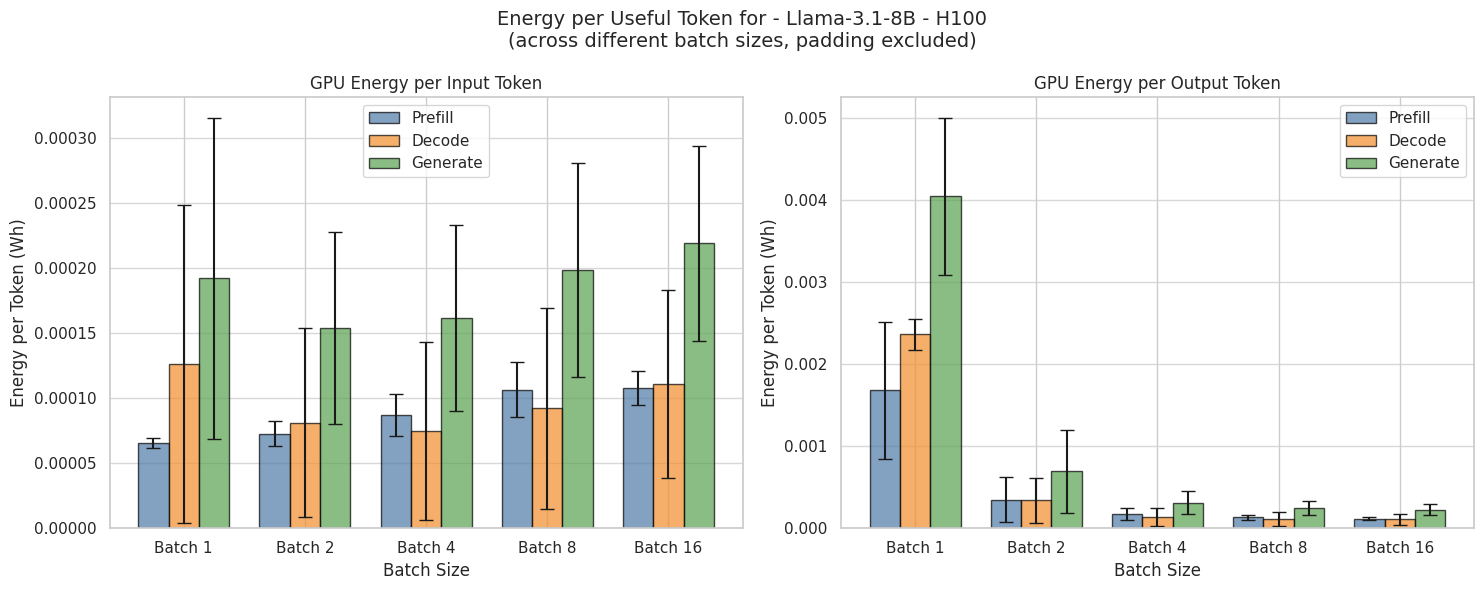

: 

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

means_input = {"prefill": [], "decode": [], "generate": []}
std_input = {"prefill": [], "decode": [], "generate": []}
means_output = {"prefill": [], "decode": [], "generate": []}
std_output = {"prefill": [], "decode": [], "generate": []}
colors = ['#4E79A7', '#F28E2B', '#59A14F']

for df in dfs_batches:
    df['prompt_tokens_all_batch'] = df['prompt_tokens'].apply(lambda x: sum(eval(x)))
    df['response_tokens_all_batch'] = df['response_tokens'].apply(lambda x: sum(eval(x)))

    for phase in ['prefill', 'decode', 'generate']:
        df[f'energy_{phase}_gpu_per_input_token'] = df[f'energy_{phase}_gpu'] * 1000 / df['prompt_tokens_all_batch']
        df[f'energy_{phase}_gpu_per_output_token'] = df[f'energy_{phase}_gpu'] * 1000 / df['response_tokens_all_batch']

        means_input[phase].append(df[f'energy_{phase}_gpu_per_input_token'].mean())
        std_input[phase].append(df[f'energy_{phase}_gpu_per_input_token'].std())
        means_output[phase].append(df[f'energy_{phase}_gpu_per_output_token'].mean())
        std_output[phase].append(df[f'energy_{phase}_gpu_per_output_token'].std())

batch_sizes = [1, 2, 4, 8, 16]
x = np.arange(len(batch_sizes))
width = 0.25

fig, ax = plt.subplots(1, 2, figsize=(15, 6))

for i, phase in enumerate(['prefill', 'decode', 'generate']):
    ax[0].bar(x + (i - 1) * width, means_input[phase], width, yerr=std_input[phase], capsize=5,
              label=phase.capitalize(), alpha=0.7, edgecolor='black', color=colors[i])

for i, phase in enumerate(['prefill', 'decode', 'generate']):
    ax[1].bar(x + (i - 1) * width, means_output[phase], width, yerr=std_output[phase], capsize=5,
              label=phase.capitalize(), alpha=0.7, edgecolor='black', color=colors[i])

for a in ax:
    a.set_xticks(x)
    a.set_xticklabels([f'Batch {s}' for s in batch_sizes])
    a.grid(axis='y', alpha=0.75)
    a.set_ylabel("Energy per Token (Wh)")
    a.set_xlabel("Batch Size")

ax[0].set_title("GPU Energy per Input Token")
ax[1].set_title("GPU Energy per Output Token")
ax[0].legend()
ax[1].legend()
plt.suptitle("Energy per Useful Token for - Llama-3.1-8B - H100\n(across different batch sizes, padding excluded)", fontsize=14)
plt.tight_layout()
plt.savefig('static/energy_per_token_llama8B_batch_sizes.png')
plt.show()



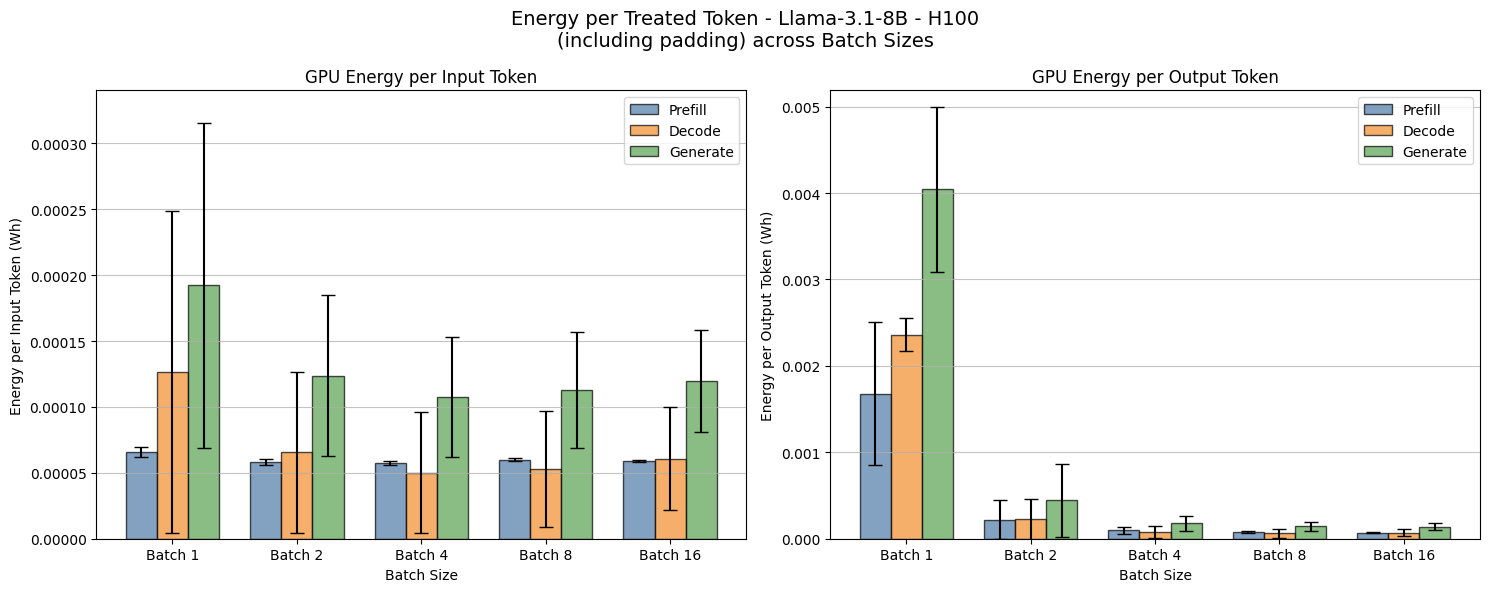

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

means_input = {"prefill": [], "decode": [], "generate": []}
std_input = {"prefill": [], "decode": [], "generate": []}
means_output = {"prefill": [], "decode": [], "generate": []}
std_output = {"prefill": [], "decode": [], "generate": []}
colors = ['#4E79A7', '#F28E2B', '#59A14F']

for df in dfs_batches:
    df['prompt_tokens_all_batch'] = df['prompt_tokens'].apply(lambda x: max(eval(x))* len(eval(x)))
    df['response_tokens_all_batch'] = df['response_tokens'].apply(lambda x: max(eval(x)) * len(eval(x)))

    for phase in ['prefill', 'decode', 'generate']:
        df[f'energy_{phase}_gpu_per_input_token'] = df[f'energy_{phase}_gpu'] * 1000 / df['prompt_tokens_all_batch']
        df[f'energy_{phase}_gpu_per_output_token'] = df[f'energy_{phase}_gpu'] * 1000 / df['response_tokens_all_batch']

        means_input[phase].append(df[f'energy_{phase}_gpu_per_input_token'].mean())
        std_input[phase].append(df[f'energy_{phase}_gpu_per_input_token'].std())
        means_output[phase].append(df[f'energy_{phase}_gpu_per_output_token'].mean())
        std_output[phase].append(df[f'energy_{phase}_gpu_per_output_token'].std())

batch_sizes = [1, 2, 4, 8, 16]
x = np.arange(len(batch_sizes))
width = 0.25

fig, ax = plt.subplots(1, 2, figsize=(15, 6))

for i, phase in enumerate(['prefill', 'decode', 'generate']):
    ax[0].bar(x + (i - 1) * width, means_input[phase], width, yerr=std_input[phase], capsize=5,
              label=phase.capitalize(), alpha=0.7, edgecolor='black', color=colors[i])
    ax[0].set_ylabel("Energy per Input Token (Wh)")

for i, phase in enumerate(['prefill', 'decode', 'generate']):
    ax[1].bar(x + (i - 1) * width, means_output[phase], width, yerr=std_output[phase], capsize=5,
              label=phase.capitalize(), alpha=0.7, edgecolor='black', color=colors[i])
    ax[1].set_ylabel("Energy per Output Token (Wh)")
for a in ax:
    a.set_xticks(x)
    a.set_xticklabels([f'Batch {s}' for s in batch_sizes])
    a.grid(axis='y', alpha=0.75)
    a.set_xlabel("Batch Size")

ax[0].set_title("GPU Energy per Input Token")
ax[1].set_title("GPU Energy per Output Token")
ax[0].set_ylim(0, max(means_input['generate']) + max(std_input['generate']) * 1.2)
ax[1].set_ylim(0, max(means_output['generate']) + max(std_output['generate']) * 1.2)
ax[0].legend()
ax[1].legend()
plt.suptitle("Energy per Treated Token - Llama-3.1-8B - H100\n(including padding) across Batch Sizes", fontsize=14)

plt.tight_layout()
plt.savefig('static/energy_per_token_llama8B_batch_sizes_padding.png')
plt.show()



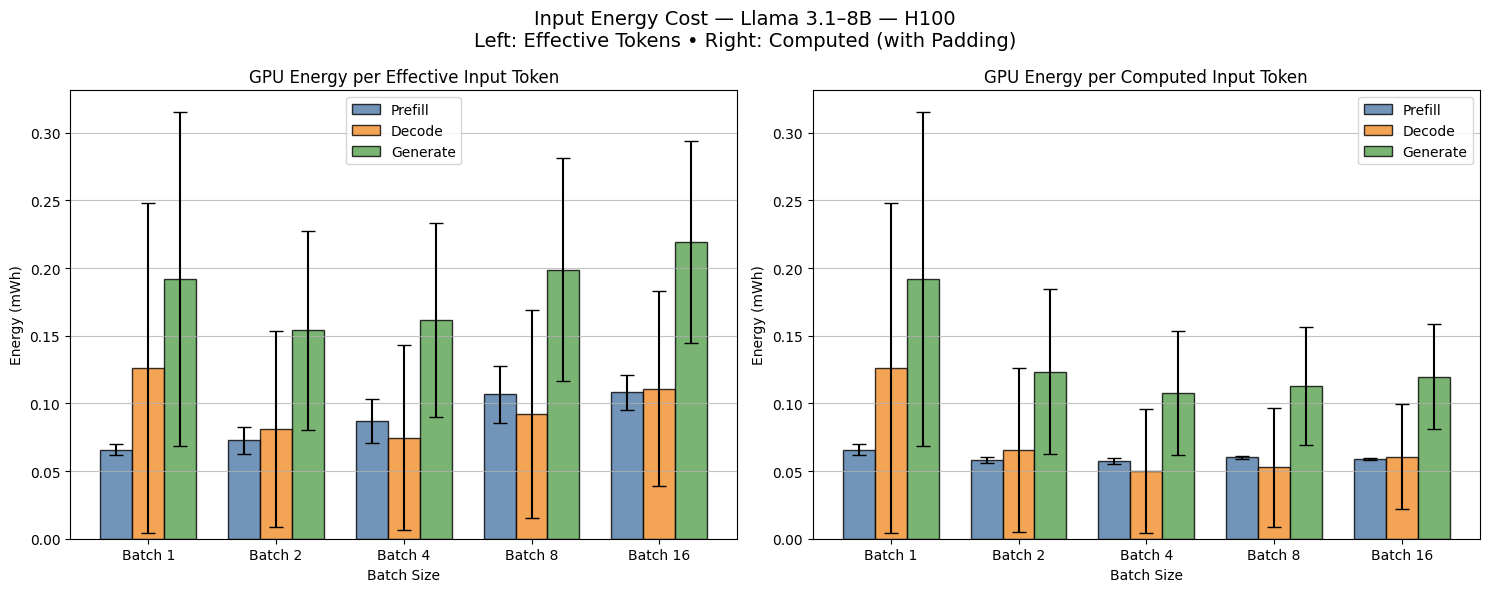

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

means_effective_input = {"prefill": [], "decode": [], "generate": []}
std_effective_input = {"prefill": [], "decode": [], "generate": []}
means_computed_input = {"prefill": [], "decode": [], "generate": []}
std_computed_input = {"prefill": [], "decode": [], "generate": []}
colors = ['#4E79A7', '#F28E2B', '#59A14F']

for df in dfs_batches:
    df['prompt_tokens_effective'] = df['prompt_tokens'].apply(lambda x: sum(eval(x)))
    df['prompt_tokens_computed'] = df['prompt_tokens'].apply(lambda x: max(eval(x)) * len(eval(x)))

    for phase in ['prefill', 'decode', 'generate']:
        df[f'energy_{phase}_gpu_per_effective_input'] = df[f'energy_{phase}_gpu'] * 1000_000 / df['prompt_tokens_effective']
        df[f'energy_{phase}_gpu_per_computed_input'] = df[f'energy_{phase}_gpu'] * 1000_000 / df['prompt_tokens_computed']

        means_effective_input[phase].append(df[f'energy_{phase}_gpu_per_effective_input'].mean())
        std_effective_input[phase].append(df[f'energy_{phase}_gpu_per_effective_input'].std())
        means_computed_input[phase].append(df[f'energy_{phase}_gpu_per_computed_input'].mean())
        std_computed_input[phase].append(df[f'energy_{phase}_gpu_per_computed_input'].std())

batch_sizes = [1, 2, 4, 8, 16]
x = np.arange(len(batch_sizes))
width = 0.25

fig, ax = plt.subplots(1, 2, figsize=(15, 6))

for i, phase in enumerate(['prefill', 'decode', 'generate']):
    ax[0].bar(x + (i - 1) * width, means_effective_input[phase], width,
              yerr=std_effective_input[phase], capsize=5,
              label=phase.capitalize(), alpha=0.8, edgecolor='black', color=colors[i])
ax[0].set_title("GPU Energy per Effective Input Token")
ax[0].set_ylabel("Energy (mWh)")
ax[0].legend()

for i, phase in enumerate(['prefill', 'decode', 'generate']):
    ax[1].bar(x + (i - 1) * width, means_computed_input[phase], width,
              yerr=std_computed_input[phase], capsize=5,
              label=phase.capitalize(), alpha=0.8, edgecolor='black', color=colors[i])
ax[1].set_title("GPU Energy per Computed Input Token")
ax[1].set_ylabel("Energy (mWh)")
ax[1].legend()

for a in ax:
    a.set_xticks(x)
    a.set_xticklabels([f'Batch {s}' for s in batch_sizes])
    a.grid(axis='y', alpha=0.75)
    a.set_xlabel("Batch Size")

plt.suptitle("Input Energy Cost — Llama 3.1–8B — H100\nLeft: Effective Tokens • Right: Computed (with Padding)", fontsize=14)
plt.tight_layout()
plt.savefig("static/energy_per_input_token_llama8B_biplot.png")
plt.show()


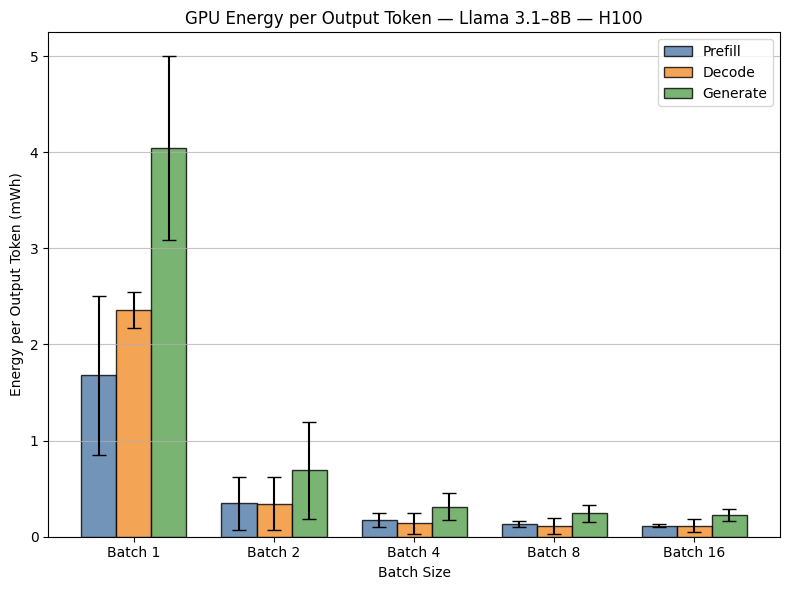

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

means_output = {"prefill": [], "decode": [], "generate": []}
std_output = {"prefill": [], "decode": [], "generate": []}
colors = ['#4E79A7', '#F28E2B', '#59A14F']


for df in dfs_batches:
    df['response_tokens_total'] = df['response_tokens'].apply(lambda x: sum(eval(x)))

    for phase in ['prefill', 'decode', 'generate']:
        df[f'energy_{phase}_gpu_per_output_token'] = df[f'energy_{phase}_gpu'] * 1000_000 / df['response_tokens_total']
        means_output[phase].append(df[f'energy_{phase}_gpu_per_output_token'].mean())
        std_output[phase].append(df[f'energy_{phase}_gpu_per_output_token'].std())

batch_sizes = [1, 2, 4, 8, 16]
x = np.arange(len(batch_sizes))
width = 0.25

fig, ax = plt.subplots(figsize=(8, 6))

for i, phase in enumerate(['prefill', 'decode', 'generate']):
    ax.bar(x + (i - 1) * width, means_output[phase], width,
           yerr=std_output[phase], capsize=5,
           label=phase.capitalize(), alpha=0.8, edgecolor='black', color=colors[i])

ax.set_xticks(x)
ax.set_xticklabels([f'Batch {s}' for s in batch_sizes])
ax.set_ylabel("Energy per Output Token (mWh)")
ax.set_xlabel("Batch Size")
ax.set_title("GPU Energy per Output Token — Llama 3.1–8B — H100")
ax.grid(axis='y', alpha=0.75)
ax.legend()

plt.tight_layout()
plt.savefig("static/energy_per_output_token_llama8B.png")
plt.show()


### latency

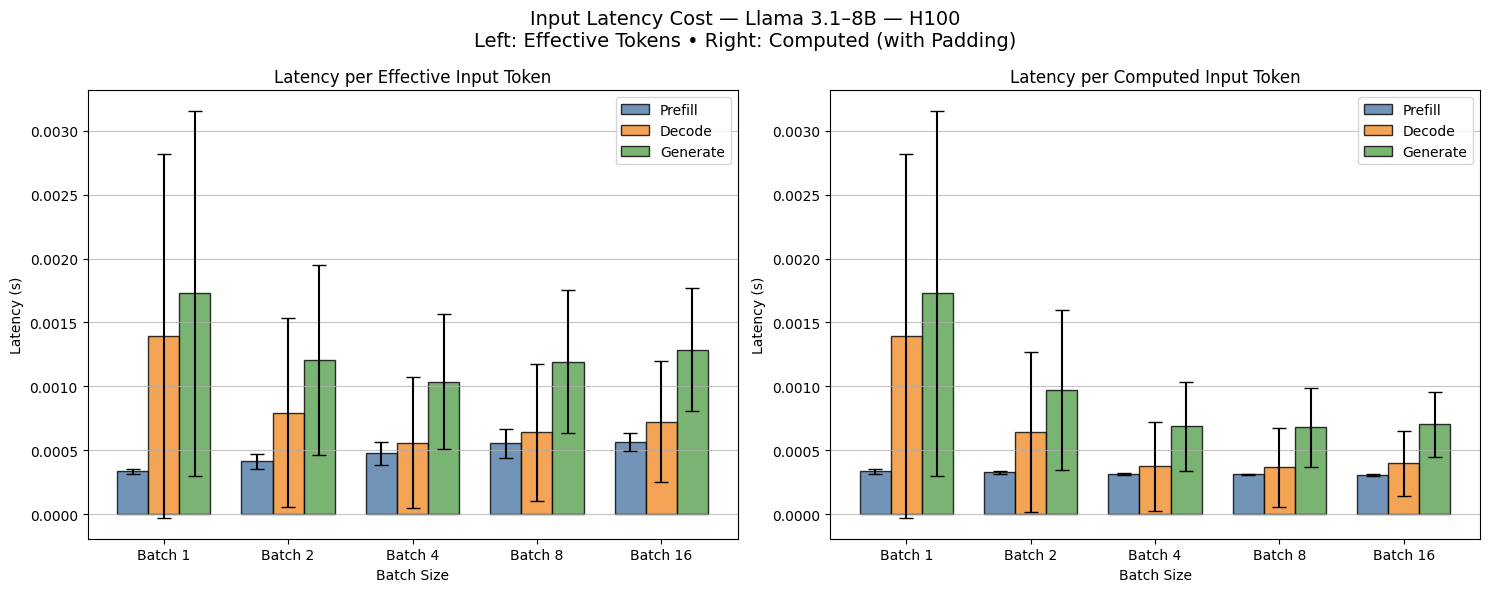

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

means_effective_input = {"prefill": [], "decode": [], "generate": []}
std_effective_input = {"prefill": [], "decode": [], "generate": []}
means_computed_input = {"prefill": [], "decode": [], "generate": []}
std_computed_input = {"prefill": [], "decode": [], "generate": []}
colors = ['#4E79A7', '#F28E2B', '#59A14F']

for df in dfs_batches:
    df['prompt_tokens_effective'] = df['prompt_tokens'].apply(lambda x: sum(eval(x)))
    df['prompt_tokens_computed'] = df['prompt_tokens'].apply(lambda x: max(eval(x)) * len(eval(x)))

    for phase in ['prefill', 'decode', 'generate']:
        df[f'duration_{phase}_per_effective_input'] = df[f'duration_{phase}'] / df['prompt_tokens_effective']
        df[f'duration_{phase}_per_computed_input'] = df[f'duration_{phase}'] / df['prompt_tokens_computed']

        means_effective_input[phase].append(df[f'duration_{phase}_per_effective_input'].mean())
        std_effective_input[phase].append(df[f'duration_{phase}_per_effective_input'].std())
        means_computed_input[phase].append(df[f'duration_{phase}_per_computed_input'].mean())
        std_computed_input[phase].append(df[f'duration_{phase}_per_computed_input'].std())

batch_sizes = [1, 2, 4, 8, 16]
x = np.arange(len(batch_sizes))
width = 0.25

fig, ax = plt.subplots(1, 2, figsize=(15, 6))

for i, phase in enumerate(['prefill', 'decode', 'generate']):
    ax[0].bar(x + (i - 1) * width, means_effective_input[phase], width,
              yerr=std_effective_input[phase], capsize=5,
              label=phase.capitalize(), alpha=0.8, edgecolor='black', color=colors[i])
ax[0].set_title("Latency per Effective Input Token")
ax[0].set_ylabel("Latency (s)")
ax[0].legend()

for i, phase in enumerate(['prefill', 'decode', 'generate']):
    ax[1].bar(x + (i - 1) * width, means_computed_input[phase], width,
              yerr=std_computed_input[phase], capsize=5,
              label=phase.capitalize(), alpha=0.8, edgecolor='black', color=colors[i])
ax[1].set_title("Latency per Computed Input Token")
ax[1].set_ylabel("Latency (s)")
ax[1].legend()

for a in ax:
    a.set_xticks(x)
    a.set_xticklabels([f'Batch {s}' for s in batch_sizes])
    a.grid(axis='y', alpha=0.75)
    a.set_xlabel("Batch Size")

plt.suptitle("Input Latency Cost — Llama 3.1–8B — H100\nLeft: Effective Tokens • Right: Computed (with Padding)", fontsize=14)
plt.tight_layout()
plt.savefig("static/latency_per_input_token_llama8B_biplot.png")
plt.show()


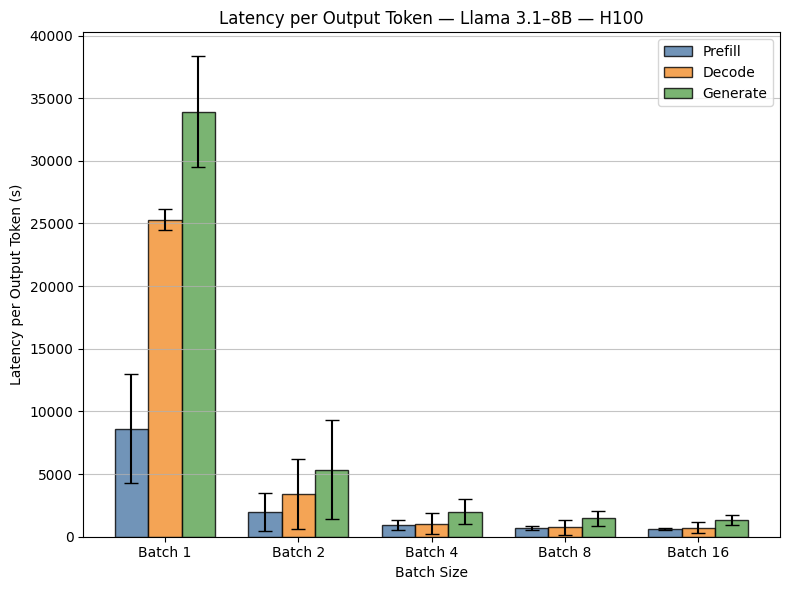

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

means_output = {"prefill": [], "decode": [], "generate": []}
std_output = {"prefill": [], "decode": [], "generate": []}
colors = ['#4E79A7', '#F28E2B', '#59A14F']

for df in dfs_batches:
    df['response_tokens_total'] = df['response_tokens'].apply(lambda x: sum(eval(x)))

    for phase in ['prefill', 'decode', 'generate']:
        df[f'duration_{phase}_per_output_token'] = df[f'duration_{phase}'] * 1000_000 / df['response_tokens_total']
        means_output[phase].append(df[f'duration_{phase}_per_output_token'].mean())
        std_output[phase].append(df[f'duration_{phase}_per_output_token'].std())


batch_sizes = [1, 2, 4, 8, 16]
x = np.arange(len(batch_sizes))
width = 0.25

fig, ax = plt.subplots(figsize=(8, 6))

for i, phase in enumerate(['prefill', 'decode', 'generate']):
    ax.bar(x + (i - 1) * width, means_output[phase], width,
           yerr=std_output[phase], capsize=5,
           label=phase.capitalize(), alpha=0.8, edgecolor='black', color=colors[i])

ax.set_xticks(x)
ax.set_xticklabels([f'Batch {s}' for s in batch_sizes])
ax.set_ylabel("Latency per Output Token (s)")
ax.set_xlabel("Batch Size")
ax.set_title("Latency per Output Token — Llama 3.1–8B — H100")
ax.grid(axis='y', alpha=0.75)
ax.legend()

plt.tight_layout()
plt.savefig("static/latency_per_output_token_llama8B.png")
plt.show()


In [109]:
dfs_batches[1][['prompt_tokens', 'response_tokens', 'prompt_tokens_all_batch', 'response_tokens_all_batch', 'energy_generate_gpu', 'energy_prefill_gpu', 'energy_decode_gpu']].head(10)

,prompt_tokens,response_tokens,prompt_tokens_all_batch,response_tokens_all_batch,energy_generate_gpu,energy_prefill_gpu,energy_decode_gpu
0,"[683, 1488]","[850, 45]",1488,850,0.000282,0.000161,0.000122
1,"[2999, 410]","[69, 2658]",2999,2658,0.000584,0.000333,0.000251
2,"[2156, 1237]","[53, 972]",2156,972,0.000410,0.000251,0.000159
3,"[1414, 1150]","[107, 371]",1414,371,0.000457,0.000160,0.000297
4,"[1965, 1311]","[46, 700]",1965,700,0.000356,0.000218,0.000138
5,"[1488, 866]","[37, 659]",1488,659,0.000267,0.000166,0.000101
6,"[903, 989]","[123, 37]",989,123,0.000202,0.000110,0.000092
7,"[1081, 912]","[42, 211]",1081,211,0.000241,0.000134,0.000107
8,"[1620, 662]","[257, 1215]",1620,1215,0.000933,0.000193,0.000739
9,"[1232, 910]","[56, 378]",1232,378,0.000290,0.000140,0.000150


## TGI

In [ ]:
import pandas as pd
FOLDER = "../data/"

In [35]:
csv_tgi_llama70B_0_0 = 'tgi-llama3-70B-ultrachat_200k-Llama-3-8B-Instruct-with-thanks-0-0-2025-06-03-15-42-26.csv'
csv_tgi_llama70B_0_005 = 'tgi-llama3-70B-ultrachat_200k-Llama-3-8B-Instruct-with-thanks-0-0_05-2025-06-03-15-07-01.csv' #
csv_tgi_llama70B_005_03 = 'ttgi-llama3-70B-ultrachat_200k-Llama-3-8B-Instruct-with-thanks-0_05-0_3-2025-06-03-16-29-22.csv' #
csv_tgi_llama70B_03_05 = 'tgi-llama3-70B-ultrachat_200k-Llama-3-8B-Instruct-with-thanks-0_3-0_5-2025-06-03-17-26-22.csv' #

csv_tgi_llama8B_0_0 = 'tgi-ultrachat_200k-Llama-3-8B-Instruct-with-thanks-0-0-2025-06-03-09-42-10.csv'
csv_tgi_llama8B_0_005 = 'tgi-ultrachat_200k-Llama-3-8B-Instruct-with-thanks-0_05-0_05-2025-06-02-16-37-42.csv'
csv_tgi_llama8B_005_03 = 'tgi-ultrachat_200k-Llama-3-8B-Instruct-with-thanks-0_05-0_3-2025-06-02-16-37-42.csv'
csv_tgi_llama8B_03_05 = 'tgi-ultrachat_200k-Llama-3-8B-Instruct-with-thanks-0_3-0_5-2025-06-02-16-37-42.csv' #
    

In [36]:
csv_tgi_llama70B_0_0 = "tgi-llama3-70B-ultrachat_200k-Llama-3-8B-Instruct-with-thanks-0-0-2025-06-03-10-43-45.csv" # bad measurement only one gpu
csv_tgi_llama70B_0_0 = "tgi-llama3-70B-ultrachat_200k-Llama-3-8B-Instruct-with-thanks-0-0-2025-06-03-15-42-26.csv"
csv_tgi_llama70B_0_005 = "tgi-llama3-70B-ultrachat_200k-Llama-3-8B-Instruct-with-thanks-0-0_05-2025-06-03-12-50-22.csv" # bad measurement only one gpu
csv_tgi_llama70B_0_005 = "tgi-llama3-70B-ultrachat_200k-Llama-3-8B-Instruct-with-thanks-0-0_05-2025-06-03-15-07-01.csv"
csv_tgi_llama70B_005_03 = "tgi-llama3-70B-ultrachat_200k-Llama-3-8B-Instruct-with-thanks-0_05-0_3-2025-06-03-16-29-22.csv"
csv_tgi_llama70B_03_05 = "tgi-llama3-70B-ultrachat_200k-Llama-3-8B-Instruct-with-thanks-0_3-0_5-2025-06-03-17-26-22.csv"

In [37]:
df_tgi_llama70B_0_0 = pd.read_csv(FOLDER + csv_tgi_llama70B_0_0)
df_tgi_llama70B_0_005 = pd.read_csv(FOLDER + csv_tgi_llama70B_0_005)
df_tgi_llama70B_005_03 = pd.read_csv(FOLDER + csv_tgi_llama70B_005_03)
df_tgi_llama70B_03_05 = pd.read_csv(FOLDER + csv_tgi_llama70B_03_05)

df_tgi_llama70B_0_0['request_waiting_time'] = '0s - 0s'
df_tgi_llama70B_0_005['request_waiting_time'] = '0s - 0.05s'
df_tgi_llama70B_005_03['request_waiting_time'] = '0.05s - 0.3s'
df_tgi_llama70B_03_05['request_waiting_time'] = '0.3s - 0.5s'

df_tgi_llama70B_0_0['model'] = 'Llama-3.1-70B-Instruct'
df_tgi_llama70B_0_005['model'] = 'Llama-3.1-70B-Instruct'
df_tgi_llama70B_005_03['model'] = 'Llama-3.1-70B-Instruct'
df_tgi_llama70B_03_05['model'] = 'Llama-3.1-70B-Instruct'
df_tgi_llama70B_0_0['total_energies'] = df_tgi_llama70B_0_0['total_energy_cpu'] + df_tgi_llama70B_0_0['total_energy_gpu'] + df_tgi_llama70B_0_0['total_energy_ram']
df_tgi_llama70B_0_005['total_energies'] = df_tgi_llama70B_0_005['total_energy_cpu'] + df_tgi_llama70B_0_005['total_energy_gpu'] + df_tgi_llama70B_0_005['total_energy_ram']
df_tgi_llama70B_005_03['total_energies'] = df_tgi_llama70B_005_03['total_energy_cpu'] + df_tgi_llama70B_005_03['total_energy_gpu'] + df_tgi_llama70B_005_03['total_energy_ram']
df_tgi_llama70B_03_05['total_energies'] = df_tgi_llama70B_03_05['total_energy_cpu'] + df_tgi_llama70B_03_05['total_energy_gpu'] + df_tgi_llama70B_03_05['total_energy_ram']
df_all_tgi_llama70B = pd.concat([
    df_tgi_llama70B_0_0,
    df_tgi_llama70B_0_005,
    df_tgi_llama70B_005_03,
    df_tgi_llama70B_03_05
])
df_all_tgi_llama70B

,total_requests,total_duration,total_energy_cpu,total_energy_gpu,total_energy_ram,request_waiting_time,model,total_energies
0,10000,2442.771972,0.030541,0.402219,0.047508,0s - 0s,Llama-3.1-70B-Instruct,0.480268
0,10000,1456.737517,0.018237,0.248904,0.028335,0s - 0.05s,Llama-3.1-70B-Instruct,0.295477
0,10000,1766.098757,0.022087,0.763797,0.034351,0.05s - 0.3s,Llama-3.1-70B-Instruct,0.820234
0,10000,4013.293646,0.105120,2.027076,0.078046,0.3s - 0.5s,Llama-3.1-70B-Instruct,2.210242


In [38]:
print(df_tgi_llama70B_0_0)

   total_requests  total_duration  total_energy_cpu  total_energy_gpu  \
0           10000     2442.771972          0.030541          0.402219   

   total_energy_ram request_waiting_time                   model  \
0          0.047508              0s - 0s  Llama-3.1-70B-Instruct   

   total_energies  
0        0.480268  


In [39]:

csv_tgi_llama8B_0_0 = 'tgi-ultrachat_200k-Llama-3-8B-Instruct-with-thanks-0-0-2025-06-03-09-42-10.csv'
csv_tgi_llama8B_0_005 = 'tgi-ultrachat_200k-Llama-3-8B-Instruct-with-thanks-0-0_05-2025-06-02-16-33-54.csv'


csv_tgi_llama8B_03_05 = 'tgi-ultrachat_200k-Llama-3-8B-Instruct-with-thanks-0_3-0_5-2025-06-02-16-37-42.csv' # bizarre très faible
csv_tgi_llama8B_03_05 = 'tgi-ultrachat_200k-Llama-3-8B-Instruct-with-thanks-0_3-0_5-2025-06-04-16-59-46.csv'

csv_tgi_llama8B_005_03 = 'tgi-ultrachat_200k-Llama-3-8B-Instruct-with-thanks-energy-0_3-0_05-2025-06-02-13-56-53.csv'

csv_tgi_llama8B_005_005 = 'tgi-ultrachat_200k-Llama-3-8B-Instruct-with-thanks-0_05-0_05-2025-06-04-17-00-04.csv'
csv_tgi_llama8B_03_03 = 'tgi-ultrachat_200k-Llama-3-8B-Instruct-with-thanks-0_3-0_3-2025-06-04-17-00-18.csv'
csv_tgi_llama8B_05_05 = 'tgi-ultrachat_200k-Llama-3-8B-Instruct-with-thanks-0_5-0_5-2025-06-04-17-00-32.csv'

df_tgi_llama8B_0_0 = pd.read_csv(FOLDER + csv_tgi_llama8B_0_0)
df_tgi_llama8B_0_005 = pd.read_csv(FOLDER + csv_tgi_llama8B_0_005)
df_tgi_llama8B_005_03 = pd.read_csv(FOLDER + csv_tgi_llama8B_005_03)
df_tgi_llama8B_03_05 = pd.read_csv(FOLDER + csv_tgi_llama8B_03_05)
df_tgi_llama8B_005_005 = pd.read_csv(FOLDER + csv_tgi_llama8B_005_005)
df_tgi_llama8B_03_03 = pd.read_csv(FOLDER + csv_tgi_llama8B_03_03)
df_tgi_llama8B_05_05 = pd.read_csv(FOLDER + csv_tgi_llama8B_05_05)
df_tgi_llama8B_0_0['request_waiting_time'] = '0s - 0s'
df_tgi_llama8B_0_005['request_waiting_time'] = '0s - 0.05s'
df_tgi_llama8B_005_03['request_waiting_time'] = '0.05s - 0.3s'
df_tgi_llama8B_03_05['request_waiting_time'] = '0.3s - 0.5s'
df_tgi_llama8B_005_005['request_waiting_time'] = '0.05s - 0.05s'
df_tgi_llama8B_03_03['request_waiting_time'] = '0.3s - 0.3s'
df_tgi_llama8B_05_05['request_waiting_time'] = '0.5s - 0.5s'
df_tgi_llama8B_0_0['model'] = 'Llama-3.1-8B-Instruct'
df_tgi_llama8B_0_005['model'] = 'Llama-3.1-8B-Instruct'
df_tgi_llama8B_005_03['model'] = 'Llama-3.1-8B-Instruct'
df_tgi_llama8B_03_05['model'] = 'Llama-3.1-8B-Instruct'
df_tgi_llama8B_005_005['model'] = 'Llama-3.1-8B-Instruct'
df_tgi_llama8B_03_03['model'] = 'Llama-3.1-8B-Instruct'
df_tgi_llama8B_05_05['model'] = 'Llama-3.1-8B-Instruct'
df_tgi_llama8B_0_0['total_energies'] = df_tgi_llama8B_0_0['total_energy_cpu'] + df_tgi_llama8B_0_0['total_energy_gpu'] +  + df_tgi_llama8B_0_0['total_energy_ram']
df_tgi_llama8B_0_005['total_energies'] = df_tgi_llama8B_0_005['total_energy_cpu'] + df_tgi_llama8B_0_005['total_energy_gpu'] +  + df_tgi_llama8B_0_005['total_energy_ram']
df_tgi_llama8B_005_03['total_energies'] = df_tgi_llama8B_005_03['total_energy_cpu'] + df_tgi_llama8B_005_03['total_energy_gpu'] +  + df_tgi_llama8B_005_03['total_energy_ram']
df_tgi_llama8B_03_05['total_energies'] = df_tgi_llama8B_03_05['total_energy_cpu'] + df_tgi_llama8B_03_05['total_energy_gpu'] +  + df_tgi_llama8B_03_05['total_energy_ram']
df_tgi_llama8B_005_005['total_energies'] = df_tgi_llama8B_005_005['total_energy_cpu'] + df_tgi_llama8B_005_005['total_energy_gpu'] +  + df_tgi_llama8B_005_005['total_energy_ram']
df_tgi_llama8B_03_03['total_energies'] = df_tgi_llama8B_03_03['total_energy_cpu'] + df_tgi_llama8B_03_03['total_energy_gpu'] +  + df_tgi_llama8B_03_03['total_energy_ram']
df_tgi_llama8B_05_05['total_energies'] = df_tgi_llama8B_05_05['total_energy_cpu'] + df_tgi_llama8B_05_05['total_energy_gpu'] +  + df_tgi_llama8B_05_05['total_energy_ram']

df_all_tgi_llama8B = pd.concat([
    df_tgi_llama8B_0_0,
    df_tgi_llama8B_0_005,
    df_tgi_llama8B_005_03,
    df_tgi_llama8B_03_05,
    df_tgi_llama8B_005_005,
    df_tgi_llama8B_03_03,
    df_tgi_llama8B_05_05
])
df_all_tgi_llama8B



,total_requests,total_duration,total_energy_cpu,total_energy_gpu,total_energy_ram,request_waiting_time,model,total_energies
0,10000,2427.434960,0.030349,0.096858,0.047210,0s - 0s,Llama-3.1-8B-Instruct,0.174417
0,10000,1340.012430,0.018104,0.116443,0.026066,0s - 0.05s,Llama-3.1-8B-Instruct,0.160613
0,10000,1772.361620,0.037003,0.229129,0.034472,0.05s - 0.3s,Llama-3.1-8B-Instruct,0.300604
0,10000,4011.001669,0.054163,0.552853,0.078002,0.3s - 0.5s,Llama-3.1-8B-Instruct,0.685017
0,10000,508.911614,0.007037,0.010651,0.009905,0.05s - 0.05s,Llama-3.1-8B-Instruct,0.027593
0,10000,3005.658376,0.040717,0.061053,0.058453,0.3s - 0.3s,Llama-3.1-8B-Instruct,0.160223
0,10000,5005.211548,0.066499,0.100941,0.097334,0.5s - 0.5s,Llama-3.1-8B-Instruct,0.264773


In [40]:
df_tgis = pd.concat([df_all_tgi_llama70B, df_all_tgi_llama8B], ignore_index=True)
df_tgis

,total_requests,total_duration,total_energy_cpu,total_energy_gpu,total_energy_ram,request_waiting_time,model,total_energies
0,10000,2442.771972,0.030541,0.402219,0.047508,0s - 0s,Llama-3.1-70B-Instruct,0.480268
1,10000,1456.737517,0.018237,0.248904,0.028335,0s - 0.05s,Llama-3.1-70B-Instruct,0.295477
2,10000,1766.098757,0.022087,0.763797,0.034351,0.05s - 0.3s,Llama-3.1-70B-Instruct,0.820234
3,10000,4013.293646,0.105120,2.027076,0.078046,0.3s - 0.5s,Llama-3.1-70B-Instruct,2.210242
4,10000,2427.434960,0.030349,0.096858,0.047210,0s - 0s,Llama-3.1-8B-Instruct,0.174417
5,10000,1340.012430,0.018104,0.116443,0.026066,0s - 0.05s,Llama-3.1-8B-Instruct,0.160613
6,10000,1772.361620,0.037003,0.229129,0.034472,0.05s - 0.3s,Llama-3.1-8B-Instruct,0.300604
7,10000,4011.001669,0.054163,0.552853,0.078002,0.3s - 0.5s,Llama-3.1-8B-Instruct,0.685017
8,10000,508.911614,0.007037,0.010651,0.009905,0.05s - 0.05s,Llama-3.1-8B-Instruct,0.027593
9,10000,3005.658376,0.040717,0.061053,0.058453,0.3s - 0.3s,Llama-3.1-8B-Instruct,0.160223


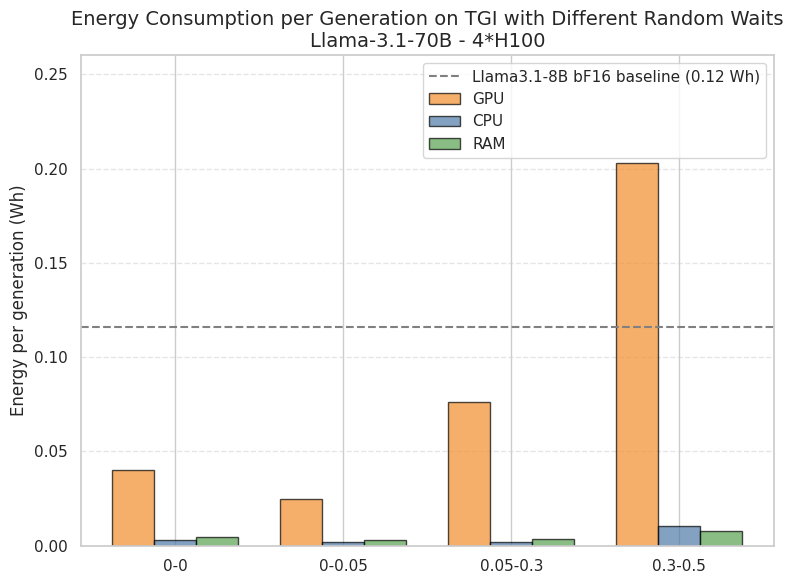

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

dataset_len = 10_000
colors = ['#4E79A7', '#F28E2B', '#59A14F']

conditions = ['0-0', '0-0.05', '0.05-0.3', '0.3-0.5']

energy_gpu = [
    df_tgi_llama70B_0_0['total_energy_gpu'].sum() * 1000 / dataset_len,
    df_tgi_llama70B_0_005['total_energy_gpu'].sum() * 1000 / dataset_len,
    df_tgi_llama70B_005_03['total_energy_gpu'].sum() * 1000 / dataset_len,
    df_tgi_llama70B_03_05['total_energy_gpu'].sum() * 1000 / dataset_len
]
energy_cpu = [
    df_tgi_llama70B_0_0['total_energy_cpu'].sum() * 1000 / dataset_len,
    df_tgi_llama70B_0_005['total_energy_cpu'].sum() * 1000 / dataset_len,
    df_tgi_llama70B_005_03['total_energy_cpu'].sum() * 1000 / dataset_len,
    df_tgi_llama70B_03_05['total_energy_cpu'].sum() * 1000 / dataset_len
]
energy_ram = [
    df_tgi_llama70B_0_0['total_energy_ram'].sum() * 1000 / dataset_len,
    df_tgi_llama70B_0_005['total_energy_ram'].sum() * 1000 / dataset_len,
    df_tgi_llama70B_005_03['total_energy_ram'].sum() * 1000 / dataset_len,
    df_tgi_llama70B_03_05['total_energy_ram'].sum() * 1000 / dataset_len
]

energy_total = [
    df_tgi_llama70B_0_0['total_energies'].sum() * 1000 / dataset_len,
    df_tgi_llama70B_0_005['total_energies'].sum() * 1000 / dataset_len,
    df_tgi_llama70B_005_03['total_energies'].sum() * 1000 / dataset_len,
    df_tgi_llama70B_03_05['total_energies'].sum() * 1000 / dataset_len
]

x = np.arange(len(conditions))
width = 0.25

plt.figure(figsize=(8, 6))
plt.bar(x - width, energy_gpu, width, label='GPU', color='#F28E2B', edgecolor='black', alpha=0.7)
plt.bar(x,         energy_cpu, width, label='CPU', color='#4E79A7', edgecolor='black', alpha=0.7)
plt.bar(x + width, energy_ram, width, label='RAM', color='#59A14F', edgecolor='black', alpha=0.7)

llama_8B_bf16_baseline = 0.11583057910569909
plt.axhline(llama_8B_bf16_baseline, linestyle='--', color='gray', linewidth=1.5, label=f'Llama3.1-8B bF16 baseline ({llama_8B_bf16_baseline:.2f} Wh)')
plt.xticks(x, conditions)
plt.ylabel('Energy per generation (Wh)')
plt.title('Energy Consumption per Generation on TGI with Different Random Waits\nLlama-3.1-70B - 4*H100', fontsize=14)
plt.ylim(0, 0.26)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('static/tgi_energy_consumption_llama70B_random_waits.png')
plt.show()



In [53]:
df_tgi_llama70B_0_005['total_energy_gpu'].sum() * 1000 / dataset_len

0.02489042966232801

In [43]:
energy_total

[0.04802683291991077,
 0.02954767840550762,
 0.08202340636191348,
 0.22102417270060987]

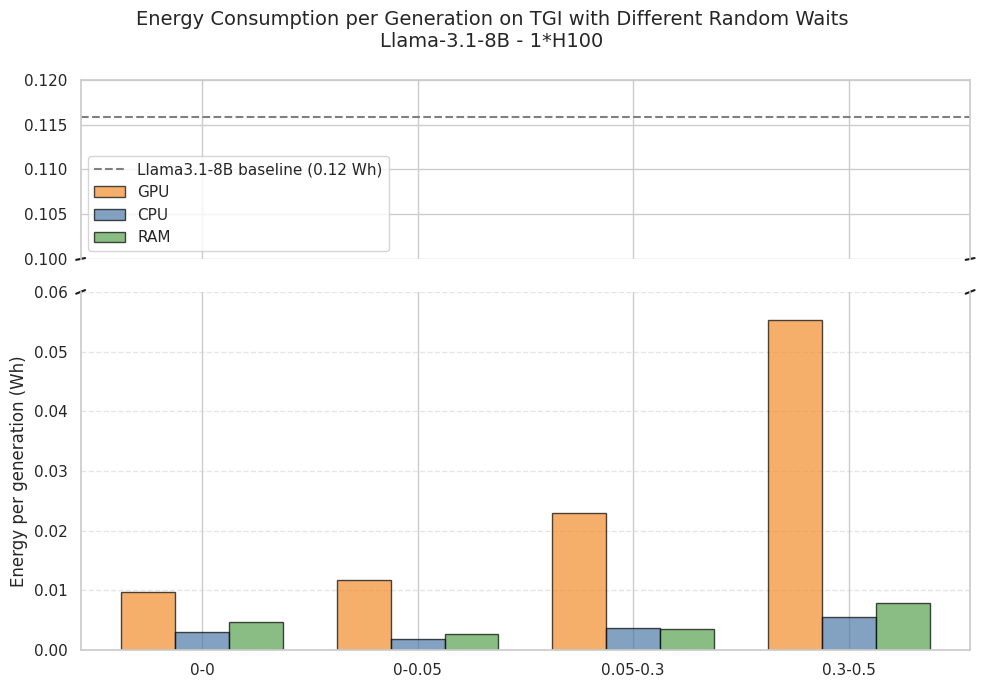

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

dataset_len = 10_000
colors = ['#4E79A7', '#F28E2B', '#59A14F']
conditions = ['0-0', '0-0.05', '0.05-0.3', '0.3-0.5']

energy_gpu = [
    df_tgi_llama8B_0_0['total_energy_gpu'].sum() * 1000 / dataset_len,
    df_tgi_llama8B_0_005['total_energy_gpu'].sum() * 1000 / dataset_len,
    df_tgi_llama8B_005_03['total_energy_gpu'].sum() * 1000 / dataset_len,
    df_tgi_llama8B_03_05['total_energy_gpu'].sum() * 1000 / dataset_len
]
energy_cpu = [
    df_tgi_llama8B_0_0['total_energy_cpu'].sum() * 1000 / dataset_len,
    df_tgi_llama8B_0_005['total_energy_cpu'].sum() * 1000 / dataset_len,
    df_tgi_llama8B_005_03['total_energy_cpu'].sum() * 1000 / dataset_len,
    df_tgi_llama8B_03_05['total_energy_cpu'].sum() * 1000 / dataset_len
]
energy_ram = [
    df_tgi_llama8B_0_0['total_energy_ram'].sum() * 1000 / dataset_len,
    df_tgi_llama8B_0_005['total_energy_ram'].sum() * 1000 / dataset_len,
    df_tgi_llama8B_005_03['total_energy_ram'].sum() * 1000 / dataset_len,
    df_tgi_llama8B_03_05['total_energy_ram'].sum() * 1000 / dataset_len
]

energy_total = [
    energy_gpu[i] + energy_cpu[i] + energy_ram[i] for i in range(len(conditions))
]

x = np.arange(len(conditions))
width = 0.25

fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(10, 7), gridspec_kw={'height_ratios': [1, 2]})
fig.subplots_adjust(hspace=0.05)

for ax in [ax1, ax2]:
    ax.bar(x - width, energy_gpu, width, label='GPU', color='#F28E2B', edgecolor='black', alpha=0.7)
    ax.bar(x,         energy_cpu, width, label='CPU', color='#4E79A7', edgecolor='black', alpha=0.7)
    ax.bar(x + width, energy_ram, width, label='RAM', color='#59A14F', edgecolor='black', alpha=0.7)

ax1.set_ylim(0.10, 0.12)
ax2.set_ylim(0, 0.06)

ax1.spines['bottom'].set_visible(False)
ax2.spines['top'].set_visible(False)
ax1.tick_params(labeltop=False)
ax2.tick_params(labeltop=False)

d = .005
kwargs = dict(transform=ax1.transAxes, color='k', clip_on=False)
ax1.plot((-d, +d), (-d, +d), **kwargs)
ax1.plot((1 - d, 1 + d), (-d, +d), **kwargs)
kwargs.update(transform=ax2.transAxes)
ax2.plot((-d, +d), (1 - d, 1 + d), **kwargs)
ax2.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)

llama_8B_bf16_baseline = 0.11583057910569909 # Baseline Llama-3.1-8B Wh
ax2.set_xticks(x)
ax2.set_xticklabels(conditions)
ax2.set_ylabel('Energy per generation (Wh)')
ax1.axhline(llama_8B_bf16_baseline, linestyle='--', color='gray', linewidth=1.5, label=f'Llama3.1-8B baseline ({llama_8B_bf16_baseline:.2f} Wh)')
ax1.legend()
ax2.grid(axis='y', linestyle='--', alpha=0.5)

fig.suptitle('Energy Consumption per Generation on TGI with Different Random Waits\nLlama-3.1-8B - 1*H100', fontsize=14)
plt.tight_layout()
plt.subplots_adjust(top=0.88)
plt.savefig('static/energy_consumption_llama8B_random_waits_broken_axis.png')
plt.show()


In [54]:
df_tgi_llama8B_0_0['total_energy_gpu'].sum() * 1000 / dataset_len

0.00968580683197188

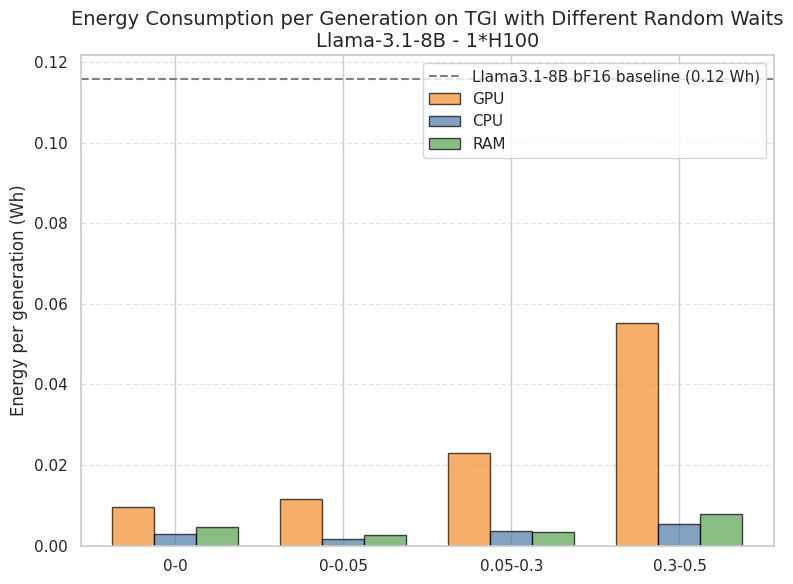

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

dataset_len = 10_000
conditions = ['0-0', '0-0.05', '0.05-0.3', '0.3-0.5']

energy_gpu = [
    df_tgi_llama8B_0_0['total_energy_gpu'].sum() * 1000 / dataset_len,
    df_tgi_llama8B_0_005['total_energy_gpu'].sum() * 1000 / dataset_len,
    df_tgi_llama8B_005_03['total_energy_gpu'].sum() * 1000 / dataset_len,
    df_tgi_llama8B_03_05['total_energy_gpu'].sum() * 1000 / dataset_len
]
energy_cpu = [
    df_tgi_llama8B_0_0['total_energy_cpu'].sum() * 1000 / dataset_len,
    df_tgi_llama8B_0_005['total_energy_cpu'].sum() * 1000 / dataset_len,
    df_tgi_llama8B_005_03['total_energy_cpu'].sum() * 1000 / dataset_len,
    df_tgi_llama8B_03_05['total_energy_cpu'].sum() * 1000 / dataset_len
]
energy_ram = [
    df_tgi_llama8B_0_0['total_energy_ram'].sum() * 1000 / dataset_len,
    df_tgi_llama8B_0_005['total_energy_ram'].sum() * 1000 / dataset_len,
    df_tgi_llama8B_005_03['total_energy_ram'].sum() * 1000 / dataset_len,
    df_tgi_llama8B_03_05['total_energy_ram'].sum() * 1000 / dataset_len
]

x = np.arange(len(conditions))
width = 0.25

fig, ax = plt.subplots(figsize=(8, 6))

ax.bar(x - width, energy_gpu, width, label='GPU', color='#F28E2B', edgecolor='black', alpha=0.7)
ax.bar(x,         energy_cpu, width, label='CPU', color='#4E79A7', edgecolor='black', alpha=0.7)
ax.bar(x + width, energy_ram, width, label='RAM', color='#59A14F', edgecolor='black', alpha=0.7)

llama_8B_bf16_baseline = 0.11583057910569909
ax.axhline(llama_8B_bf16_baseline, linestyle='--', color='gray', linewidth=1.5, label=f'Llama3.1-8B bF16 baseline ({llama_8B_bf16_baseline:.2f} Wh)')

ax.set_xticks(x)
ax.set_xticklabels(conditions)
ax.set_ylabel('Energy per generation (Wh)')
ax.set_title('Energy Consumption per Generation on TGI with Different Random Waits\nLlama-3.1-8B - 1*H100', fontsize=14)
ax.legend(loc='upper right')
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('static/tgi_energy_consumption_llama8B_random_waits.png')
plt.show()


In [240]:
energy_total

[np.float64(0.01744172196581431),
 np.float64(0.01606132054653845),
 np.float64(0.03006040711069174),
 np.float64(0.06850166310254396)]

In [58]:
df_tgi_llama8B_005_005['total_energy_gpu'].sum() * 1000 / dataset_len
print(f"GPU Energy for 0.05-0.05: {df_tgi_llama8B_005_005['total_energy_gpu'].sum() * 1000 / dataset_len:.4f} Wh")
print(f"GPU Energy for 0.3-0.3: {df_tgi_llama8B_03_03['total_energy_gpu'].sum() * 1000 / dataset_len:.4f} Wh")
print(f"GPU Energy for 0.5-0.5: {df_tgi_llama8B_05_05['total_energy_gpu'].sum() * 1000 / dataset_len:.4f} Wh")

GPU Energy for 0.05-0.05: 0.0011 Wh
GPU Energy for 0.3-0.3: 0.0061 Wh
GPU Energy for 0.5-0.5: 0.0101 Wh


In [56]:
df_tgi_llama8B_03_03['total_energy_gpu'].sum() * 1000 / dataset_len

0.00610525007864168

In [57]:
df_tgi_llama8B_05_05['total_energy_gpu'].sum() * 1000 / dataset_len

0.010094115630843701

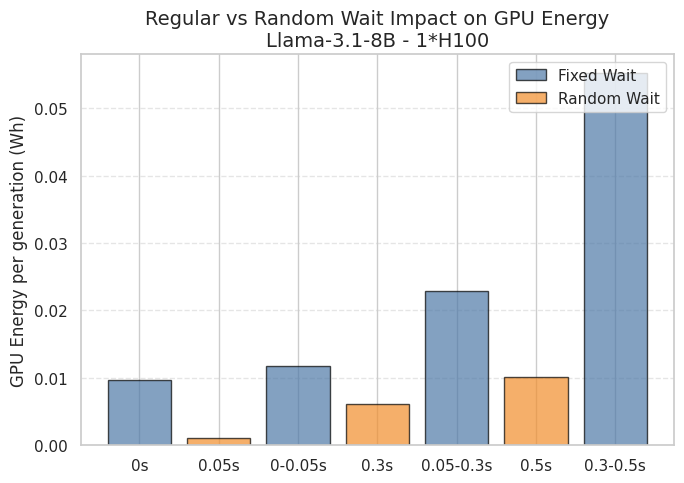

<Figure size 640x480 with 0 Axes>

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

conditions = ['0s', '0.05s', '0-0.05s', '0.3s', '0.05-0.3s', '0.5s', '0.3-0.5s']
energy_gpu_comparison = [
    df_tgi_llama8B_0_0['total_energy_gpu'].sum() * 1000 / dataset_len,  # 0s fixed
    df_tgi_llama8B_005_005['total_energy_gpu'].sum() * 1000 / dataset_len,  # 0.05s fixed
    df_tgi_llama8B_0_005['total_energy_gpu'].sum() * 1000 / dataset_len,       # 0-0.05s random
    df_tgi_llama8B_03_03['total_energy_gpu'].sum() * 1000 / dataset_len,   # 0.3s fixed
    df_tgi_llama8B_005_03['total_energy_gpu'].sum() * 1000 / dataset_len,        # 0.3-0.5s random
    df_tgi_llama8B_05_05['total_energy_gpu'].sum() * 1000 / dataset_len,  # 0.5s fixed
    df_tgi_llama8B_03_05['total_energy_gpu'].sum() * 1000 / dataset_len  # 0.3-0.5s random
]

x = np.arange(len(conditions))

plt.figure(figsize=(7, 5))
plt.bar(x, energy_gpu_comparison, color=['#4E79A7', '#F28E2B', '#4E79A7', '#F28E2B'], edgecolor='black', alpha=0.7, label=['fixed', 'random', 'fixed', 'random', 'fixed', 'random', 'fixed'])

plt.xticks(x, conditions)
plt.ylabel('GPU Energy per generation (Wh)')
plt.title('Regular vs Random Wait Impact on GPU Energy\nLlama-3.1-8B - 1*H100', fontsize=14)
plt.ylim(0, max(energy_gpu_comparison) * 1.05)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(['Fixed Wait', 'Random Wait'], loc='upper right')
plt.tight_layout()
plt.savefig('static/energy_consumption_llama8B_fixed_vs_random_waits.png')
plt.show()



In [248]:
energy_gpu_comparison

[np.float64(0.00968580683197188),
 np.float64(0.0010650698242784498),
 np.float64(0.01164432009322631),
 np.float64(0.00610525007864168),
 np.float64(0.02291285955249691),
 np.float64(0.010094115630843701),
 np.float64(0.055285253978169635)]

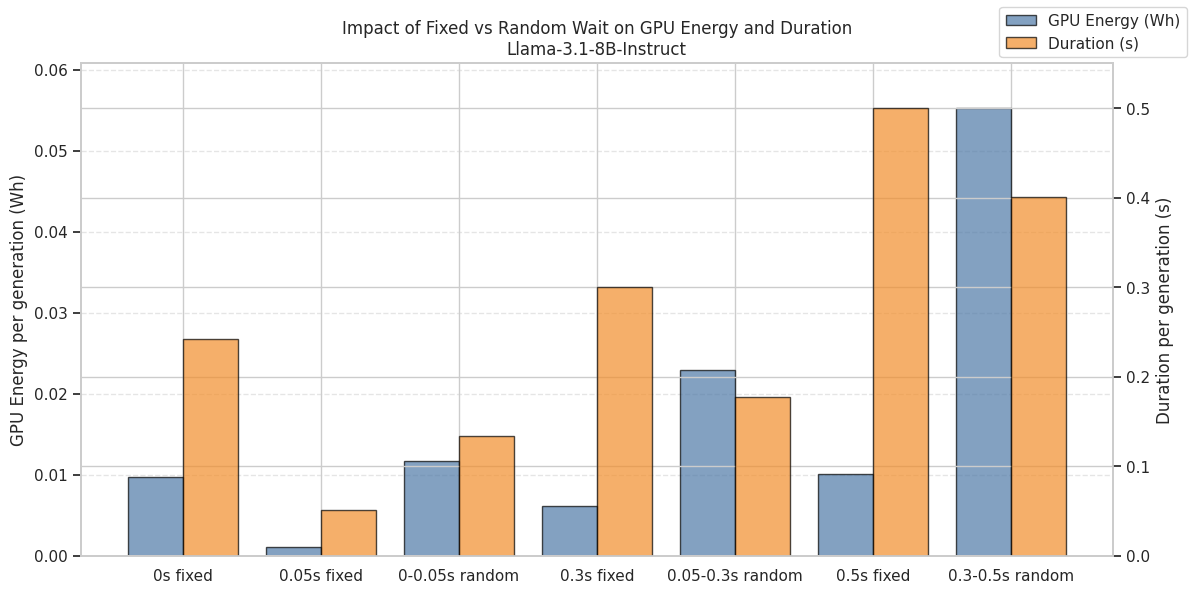

<Figure size 640x480 with 0 Axes>

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

conditions = ['0s fixed', '0.05s fixed', '0-0.05s random', '0.3s fixed', '0.05-0.3s random', '0.5s fixed', '0.3-0.5s random']
dataset_len = 10_000

energy_gpu = [
    df_tgi_llama8B_0_0['total_energy_gpu'].sum() * 1000 / dataset_len,
    df_tgi_llama8B_005_005['total_energy_gpu'].sum() * 1000 / dataset_len,
    df_tgi_llama8B_0_005['total_energy_gpu'].sum() * 1000 / dataset_len,
    df_tgi_llama8B_03_03['total_energy_gpu'].sum() * 1000 / dataset_len,
    df_tgi_llama8B_005_03['total_energy_gpu'].sum() * 1000 / dataset_len,
    df_tgi_llama8B_05_05['total_energy_gpu'].sum() * 1000 / dataset_len,
    df_tgi_llama8B_03_05['total_energy_gpu'].sum() * 1000 / dataset_len
]

duration = [
    df_tgi_llama8B_0_0['total_duration'].sum() / dataset_len,
    df_tgi_llama8B_005_005['total_duration'].sum() / dataset_len,
    df_tgi_llama8B_0_005['total_duration'].sum() / dataset_len,
    df_tgi_llama8B_03_03['total_duration'].sum() / dataset_len,
    df_tgi_llama8B_005_03['total_duration'].sum() / dataset_len,
    df_tgi_llama8B_05_05['total_duration'].sum() / dataset_len,
    df_tgi_llama8B_03_05['total_duration'].sum() / dataset_len
]

x = np.arange(len(conditions))
width = 0.4

fig, ax1 = plt.subplots(figsize=(12, 6))

bars1 = ax1.bar(x - width/2, energy_gpu, width, label='GPU Energy (Wh)', color='#4E79A7', edgecolor='black', alpha=0.7)
ax1.set_ylabel('GPU Energy per generation (Wh)')
ax1.tick_params(axis='y')

ax1.set_ylim(0, max(energy_gpu) * 1.1)

ax2 = ax1.twinx()
bars2 = ax2.bar(x + width/2, duration, width, label='Duration (s)', color='#F28E2B', edgecolor='black', alpha=0.7)
ax2.set_ylabel('Duration per generation (s)')
ax2.tick_params(axis='y')
ax2.set_ylim(0, max(duration) * 1.1)

plt.xticks(x, conditions, rotation=15)
plt.title('Impact of Fixed vs Random Wait on GPU Energy and Duration\nLlama-3.1-8B-Instruct')
ax1.grid(axis='y', linestyle='--', alpha=0.5)

lines = [bars1, bars2]
labels = [bar.get_label() for bar in lines]
fig.legend(lines, labels, loc='upper right')

plt.tight_layout()
plt.show()
plt.savefig('static/energy_duration_llama8B_fixed_vs_random_waits.png')


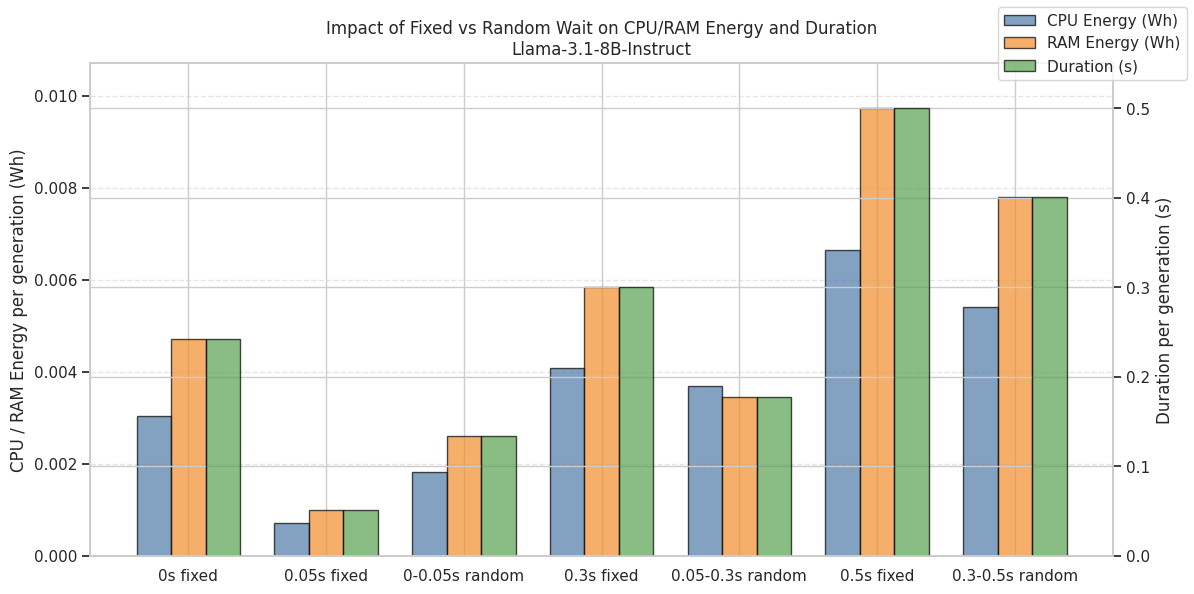

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

conditions = ['0s fixed', '0.05s fixed', '0-0.05s random', '0.3s fixed', '0.05-0.3s random', '0.5s fixed', '0.3-0.5s random']
colors = ['#4E79A7', '#F28E2B', '#59A14F']
colors = ['#4E79A7', '#F28E2B', '#59A14F']

energy_cpu = [
    df_tgi_llama8B_0_0['total_energy_cpu'].sum() * 1000 / dataset_len,
    df_tgi_llama8B_005_005['total_energy_cpu'].sum() * 1000 / dataset_len,
    df_tgi_llama8B_0_005['total_energy_cpu'].sum() * 1000 / dataset_len,
    df_tgi_llama8B_03_03['total_energy_cpu'].sum() * 1000 / dataset_len,
    df_tgi_llama8B_005_03['total_energy_cpu'].sum() * 1000 / dataset_len,
    df_tgi_llama8B_05_05['total_energy_cpu'].sum() * 1000 / dataset_len,
    df_tgi_llama8B_03_05['total_energy_cpu'].sum() * 1000 / dataset_len
]

energy_ram = [
    df_tgi_llama8B_0_0['total_energy_ram'].sum() * 1000 / dataset_len,
    df_tgi_llama8B_005_005['total_energy_ram'].sum() * 1000 / dataset_len,
    df_tgi_llama8B_0_005['total_energy_ram'].sum() * 1000 / dataset_len,
    df_tgi_llama8B_03_03['total_energy_ram'].sum() * 1000 / dataset_len,
    df_tgi_llama8B_005_03['total_energy_ram'].sum() * 1000 / dataset_len,
    df_tgi_llama8B_05_05['total_energy_ram'].sum() * 1000 / dataset_len,
    df_tgi_llama8B_03_05['total_energy_ram'].sum() * 1000 / dataset_len
]

duration = [
    df_tgi_llama8B_0_0['total_duration'].sum() / dataset_len,
    df_tgi_llama8B_005_005['total_duration'].sum() / dataset_len,
    df_tgi_llama8B_0_005['total_duration'].sum() / dataset_len,
    df_tgi_llama8B_03_03['total_duration'].sum() / dataset_len,
    df_tgi_llama8B_005_03['total_duration'].sum() / dataset_len,
    df_tgi_llama8B_05_05['total_duration'].sum() / dataset_len,
    df_tgi_llama8B_03_05['total_duration'].sum() / dataset_len
]

x = np.arange(len(conditions))
width = 0.25

fig, ax1 = plt.subplots(figsize=(12, 6))

bars_cpu = ax1.bar(x - width, energy_cpu, width=width, label='CPU Energy (Wh)', color=colors[0], edgecolor='black', alpha=0.7)
bars_ram = ax1.bar(x, energy_ram, width=width, label='RAM Energy (Wh)', color=colors[1], edgecolor='black', alpha=0.7)
ax1.set_ylabel('CPU / RAM Energy per generation (Wh)')
ax1.tick_params(axis='y')
ax1.set_ylim(0, max(max(energy_cpu), max(energy_ram)) * 1.1)

ax2 = ax1.twinx()
bars_duration = ax2.bar(x + width, duration, width=width, label='Duration (s)', color=colors[2], edgecolor='black', alpha=0.7)
ax2.set_ylabel('Duration per generation (s)')
ax2.tick_params(axis='y')
ax2.set_ylim(0, max(duration) * 1.1)

plt.xticks(x, conditions, rotation=15)
plt.title('Impact of Fixed vs Random Wait on CPU/RAM Energy and Duration\nLlama-3.1-8B-Instruct')
ax1.grid(axis='y', linestyle='--', alpha=0.5)

lines = [bars_cpu, bars_ram, bars_duration]
labels = [bar.get_label() for bar in lines]
fig.legend(lines, labels, loc='upper right')

plt.tight_layout()
plt.show()


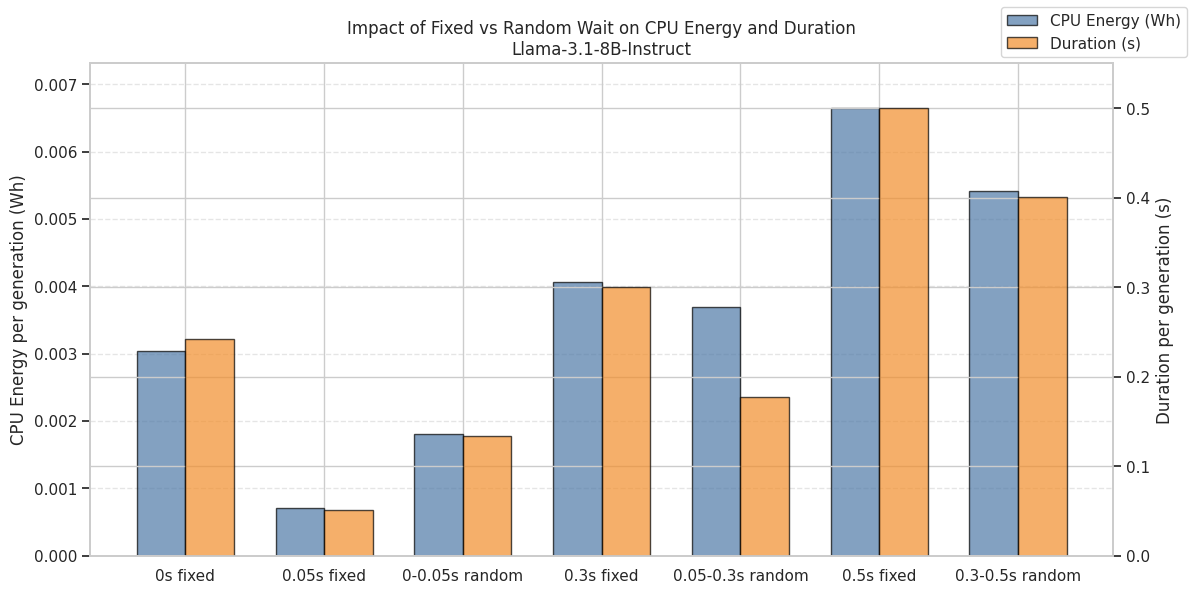

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

conditions = ['0s fixed', '0.05s fixed', '0-0.05s random', '0.3s fixed', '0.05-0.3s random', '0.5s fixed', '0.3-0.5s random']

energy_cpu = [
    df_tgi_llama8B_0_0['total_energy_cpu'].sum() * 1000 / dataset_len,
    df_tgi_llama8B_005_005['total_energy_cpu'].sum() * 1000 / dataset_len,
    df_tgi_llama8B_0_005['total_energy_cpu'].sum() * 1000 / dataset_len,
    df_tgi_llama8B_03_03['total_energy_cpu'].sum() * 1000 / dataset_len,
    df_tgi_llama8B_005_03['total_energy_cpu'].sum() * 1000 / dataset_len,
    df_tgi_llama8B_05_05['total_energy_cpu'].sum() * 1000 / dataset_len,
    df_tgi_llama8B_03_05['total_energy_cpu'].sum() * 1000 / dataset_len
]

duration = [
    df_tgi_llama8B_0_0['total_duration'].sum() / dataset_len,
    df_tgi_llama8B_005_005['total_duration'].sum() / dataset_len,
    df_tgi_llama8B_0_005['total_duration'].sum() / dataset_len,
    df_tgi_llama8B_03_03['total_duration'].sum() / dataset_len,
    df_tgi_llama8B_005_03['total_duration'].sum() / dataset_len,
    df_tgi_llama8B_05_05['total_duration'].sum() / dataset_len,
    df_tgi_llama8B_03_05['total_duration'].sum() / dataset_len
]

x = np.arange(len(conditions))
width = 0.35

fig, ax1 = plt.subplots(figsize=(12, 6))

bars_cpu = ax1.bar(x - width/2, energy_cpu, width=width, label='CPU Energy (Wh)', color='#4E79A7', edgecolor='black', alpha=0.7)
ax1.set_ylabel('CPU Energy per generation (Wh)')
ax1.tick_params(axis='y')
ax1.set_ylim(0, max(energy_cpu) * 1.1)

ax2 = ax1.twinx()
bars_duration = ax2.bar(x + width/2, duration, width=width, label='Duration (s)', color='#F28E2B', edgecolor='black', alpha=0.7)
ax2.set_ylabel('Duration per generation (s)')
ax2.tick_params(axis='y')
ax2.set_ylim(0, max(duration) * 1.1)

plt.xticks(x, conditions, rotation=15)
plt.title('Impact of Fixed vs Random Wait on CPU Energy and Duration\nLlama-3.1-8B-Instruct')
ax1.grid(axis='y', linestyle='--', alpha=0.5)

lines = [bars_cpu, bars_duration]
labels = [bar.get_label() for bar in lines]
fig.legend(lines, labels, loc='upper right')

plt.tight_layout()
plt.show()


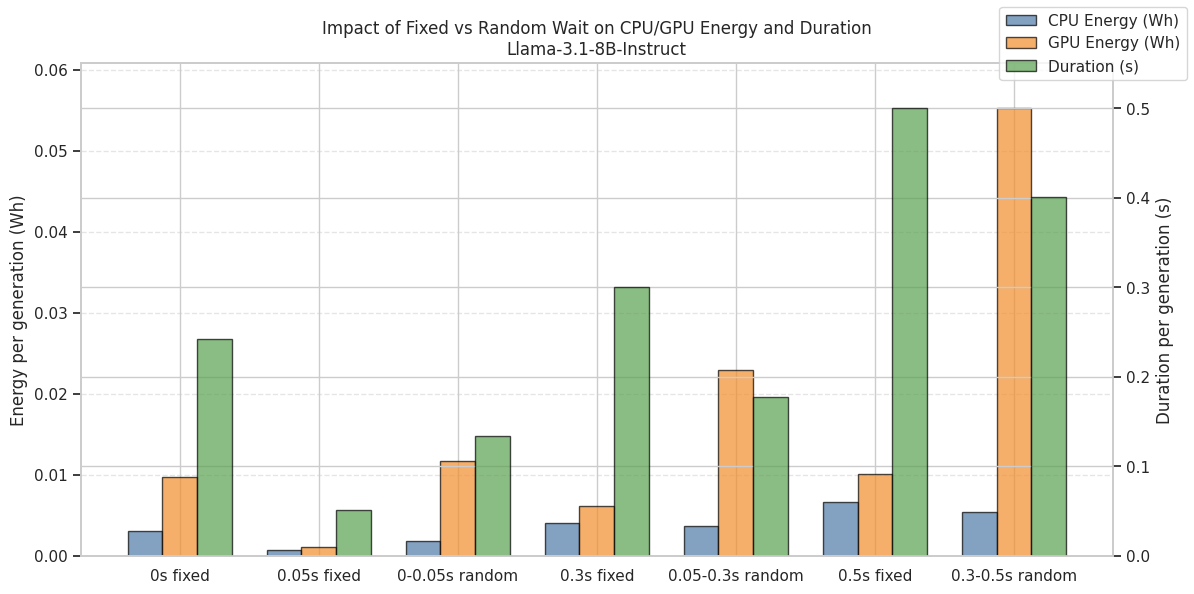

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

conditions = ['0s fixed', '0.05s fixed', '0-0.05s random', '0.3s fixed', '0.05-0.3s random', '0.5s fixed', '0.3-0.5s random']
colors = ['#4E79A7', '#F28E2B', '#59A14F']

energy_cpu = [
    df_tgi_llama8B_0_0['total_energy_cpu'].sum() * 1000 / dataset_len,
    df_tgi_llama8B_005_005['total_energy_cpu'].sum() * 1000 / dataset_len,
    df_tgi_llama8B_0_005['total_energy_cpu'].sum() * 1000 / dataset_len,
    df_tgi_llama8B_03_03['total_energy_cpu'].sum() * 1000 / dataset_len,
    df_tgi_llama8B_005_03['total_energy_cpu'].sum() * 1000 / dataset_len,
    df_tgi_llama8B_05_05['total_energy_cpu'].sum() * 1000 / dataset_len,
    df_tgi_llama8B_03_05['total_energy_cpu'].sum() * 1000 / dataset_len
]

energy_gpu = [
    df_tgi_llama8B_0_0['total_energy_gpu'].sum() * 1000 / dataset_len,
    df_tgi_llama8B_005_005['total_energy_gpu'].sum() * 1000 / dataset_len,
    df_tgi_llama8B_0_005['total_energy_gpu'].sum() * 1000 / dataset_len,
    df_tgi_llama8B_03_03['total_energy_gpu'].sum() * 1000 / dataset_len,
    df_tgi_llama8B_005_03['total_energy_gpu'].sum() * 1000 / dataset_len,
    df_tgi_llama8B_05_05['total_energy_gpu'].sum() * 1000 / dataset_len,
    df_tgi_llama8B_03_05['total_energy_gpu'].sum() * 1000 / dataset_len
]

duration = [
    df_tgi_llama8B_0_0['total_duration'].sum() / dataset_len,
    df_tgi_llama8B_005_005['total_duration'].sum() / dataset_len,
    df_tgi_llama8B_0_005['total_duration'].sum() / dataset_len,
    df_tgi_llama8B_03_03['total_duration'].sum() / dataset_len,
    df_tgi_llama8B_005_03['total_duration'].sum() / dataset_len,
    df_tgi_llama8B_05_05['total_duration'].sum() / dataset_len,
    df_tgi_llama8B_03_05['total_duration'].sum() / dataset_len
]

x = np.arange(len(conditions))
width = 0.25

fig, ax1 = plt.subplots(figsize=(12, 6))

bars_cpu = ax1.bar(x - width, energy_cpu, width=width, label='CPU Energy (Wh)', color=colors[0], edgecolor='black', alpha=0.7)
bars_gpu = ax1.bar(x, energy_gpu, width=width, label='GPU Energy (Wh)', color=colors[1], edgecolor='black', alpha=0.7)
ax1.set_ylabel('Energy per generation (Wh)')
ax1.tick_params(axis='y')
ax1.set_ylim(0, max(max(energy_cpu), max(energy_gpu)) * 1.1)

ax2 = ax1.twinx()
bars_duration = ax2.bar(x + width, duration, width=width, label='Duration (s)', color=colors[2], edgecolor='black', alpha=0.7)
ax2.set_ylabel('Duration per generation (s)')
ax2.tick_params(axis='y')
ax2.set_ylim(0, max(duration) * 1.1)

plt.xticks(x, conditions, rotation=15)
plt.title('Impact of Fixed vs Random Wait on CPU/GPU Energy and Duration\nLlama-3.1-8B-Instruct')
ax1.grid(axis='y', linestyle='--', alpha=0.5)

lines = [bars_cpu, bars_gpu, bars_duration]
labels = [bar.get_label() for bar in lines]
fig.legend(lines, labels, loc='upper right')

plt.tight_layout()
plt.show()
